# Phantom Eigenmode Fabrication from Measurement Gaps
**Working Document — April 2026**

*Companion to: Compression–Commutator Geometry (v3)*

---

## Preface

This document develops the hole problem from the ground up — starting from the physical observation that motivated the work, building to exact operator theory, and ending with concrete engineering tools. It is the application layer; the companion CCG document is the abstract framework.

The development record is part of the content. What was in the original suite, what was wrong, where corrections came from, and what is still open are all stated explicitly. The goal is an accurate working record of ideas, not a polished artifact that hides how we got here.

Three things make the hole problem non-obvious despite its simple setup. First, the exact outside-gap phantom field does not decay with distance from the gap — in the simple-spectrum case it is a spatially uniform scaled copy of the true mode, and in the degenerate case it is a scaled eigenspace vector (still non-decaying, but generally not a scalar multiple of the original mode unless the source lies in a mask-adapted eigendirection). Second, the near-gap localization that practitioners actually see is a finite-bandwidth artifact, not a property of the exact operator. Third, the visible finite-band artifact and the exact modal lie are different objects that need separate treatment. Conflating them is the source of most of the confusion in the original suite.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import sici, jv
from scipy.optimize import brentq

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'grid.color': 'white',
    'grid.linewidth': 1.2,
})


---
## Part I — The Observation and the Setup

### 1.1 What Started This

A rounded rectangle with a four-lobed mode shape and a measurement gap covering one lobe. Three lobes were visible in the measured data. The natural reading: three real features, one hidden. The instinct that launched this work was the opposite: all three visible lobes are phantom. The hole is not hiding a fourth feature — it is manufacturing all three.

Two aspects of this instinct were important. First, the phantom structure was a property of the hole geometry, not of whatever physical signal might lie beneath it. Second, the three visible lobes were the ones nearest to the gap. The fourth — diametrically opposite — was absent. The phantom effect appeared distance-dependent: strongest near the hole, decaying away from it.

Both aspects turned out to be correct, but for different reasons at different levels of the analysis. The working process of separating those levels is the main content of this document.

### 1.2 The Setup

Let $L$ be a self-adjoint operator on a domain $\Omega$ with orthonormal eigenbasis $\{\varphi_n\}$, eigenvalues $\{\lambda_n\}$, eigenspace projectors $P_\lambda$. In practice $L$ is the Laplacian $(-\Delta)$ with Dirichlet boundary conditions, making the $\varphi_n$ the vibrational modes of a membrane or the spectral modes of a wave field.

A measurement gap $G \subset \Omega$ is a spatial region where no data is collected. The mask operator is:
$$M_G = I - \chi_G,$$
where $\chi_G$ is the indicator function of $G$. The observed field is $y = M_G f$. The analysis pipeline projects $y$ onto the original eigenbasis and interprets the resulting coefficients as physical quantities.

Observed (corrupted) coefficients:
$$\hat{c}_m = \langle M_G f, \varphi_m\rangle = \sum_n A_{mn} c_n, \qquad A_{mn} = \delta_{mn} - K_{mn}, \quad K_{mn} = \int_G \varphi_n\,\bar{\varphi}_m.$$

The matrix $K$ is the coupling kernel — determined entirely by the gap geometry and the eigenbasis, independent of the signal. $A = I - K$ is the forward operator mapping true coefficients to observed coefficients. Every phantom problem is a consequence of the off-diagonal entries of $K$.

### 1.3 What the Hole Actually Does

The hole does not merely remove information. It changes the effective inner product on the modal coordinates. The naive projection $\hat{c}_m = \langle y, \varphi_m\rangle$ treats $\{\varphi_n\}$ as orthonormal under the full-domain inner product. But $\{M_G \varphi_n\}$ is the actual measurement dictionary, and its Gram matrix is:
$$G_{mn} = \langle M_G \varphi_n, M_G \varphi_m\rangle = \langle M_G^2 \varphi_n, \varphi_m\rangle = \langle M_G \varphi_n, \varphi_m\rangle = A_{mn},$$
using $M_G^2 = M_G$ (idempotency of the hard mask). The correct least-squares problem uses the masked dictionary $\{M_G \varphi_n\}$ with Gram matrix $A$. The naive analyst treats $A$ as the identity. Phantom fabrication is exactly the penalty for using the wrong inner product.

**This is the cleanest statement of what goes wrong: the analyst is doing least squares in the wrong geometry.**


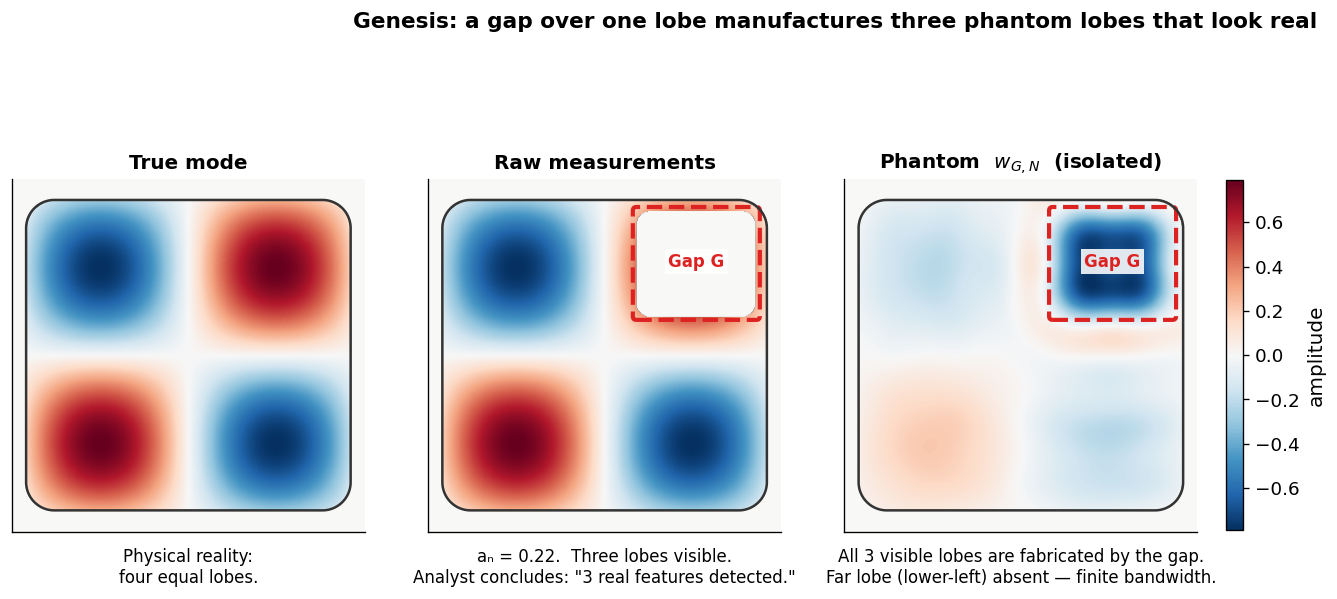

a_n = 0.2158


In [2]:

import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches

N_grid = 320
x = np.linspace(0,1,N_grid); y = np.linspace(0,1,N_grid)
X, Y = np.meshgrid(x, y)

def sdf_rr(X,Y,cx,cy,hw,hh,r):
    dx=np.abs(X-cx)-hw+r; dy=np.abs(Y-cy)-hh+r
    return np.sqrt(np.maximum(dx,0)**2+np.maximum(dy,0)**2)-r+np.minimum(np.maximum(dx,dy),0)

domain = sdf_rr(X,Y,0.5,0.5,0.46,0.44,0.08)<=0
psi_full = np.sin(2*np.pi*X)*np.sin(2*np.pi*Y)
psi = psi_full.copy(); psi[~domain]=np.nan
gap = (sdf_rr(X,Y,0.76,0.76,0.17,0.15,0.04)<=0)&domain
a_n = np.nansum(psi_full[gap]**2)/np.nansum(psi_full[domain]**2)
psi_obs = psi.copy(); psi_obs[gap]=np.nan

N_bw=12; dx2=(1.0/N_grid)**2; w_GN=np.zeros((N_grid,N_grid))
for m in range(1,N_bw+1):
    for n in range(1,N_bw+1):
        if m==2 and n==2: continue
        if m*m+n*n>N_bw*N_bw: continue
        phi_mn=2.0*np.sin(m*np.pi*X)*np.sin(n*np.pi*Y)
        w_GN+=(-np.sum(psi_full[gap]*phi_mn[gap])*dx2)*phi_mn
w_GN[~domain]=np.nan
vmax=float(np.nanmax(np.abs(psi_full[domain])))
vmax_ph=max(float(np.nanmax(np.abs(w_GN[domain]))),0.01)

fig, axes = plt.subplots(1, 3, figsize=(14, 6.5))
# generous bottom for xlabels, top for suptitle, space between panels
fig.subplots_adjust(left=0.01, right=0.86, top=0.86, bottom=0.22, wspace=0.18)

cmap='RdBu_r'
titles   = ['True mode', 'Raw measurements', r'Phantom  $w_{G,N}$  (isolated)']
xlabels  = [
    'Physical reality:\nfour equal lobes.',
    f'a\u2099 = {a_n:.2f}.  Three lobes visible.\nAnalyst concludes: "3 real features detected."',
    'All 3 visible lobes are fabricated by the gap.\nFar lobe (lower-left) absent — finite bandwidth.',
]
vmaxes = [vmax, vmax, vmax_ph]

for ax, field, title, xlabel, vm in zip(axes, [psi,psi_obs,w_GN], titles, xlabels, vmaxes):
    im = ax.imshow(field, cmap=cmap, vmin=-vm, vmax=vm,
                   origin='lower', extent=[0,1,0,1], aspect='equal')
    ax.contour(X,Y,sdf_rr(X,Y,0.5,0.5,0.46,0.44,0.08),levels=[0],colors=['#333'],linewidths=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(xlabel, fontsize=10, labelpad=10, color='black')

# Gap box on panels 1 and 2
for ax in axes[1:]:
    ax.add_patch(mpatches.FancyBboxPatch((0.59,0.61),0.34,0.30,
        boxstyle='round,pad=0.01',fill=False,edgecolor='#dd2222',linewidth=2.5,linestyle='--'))
    ax.text(0.76,0.765,'Gap G', ha='center', va='center', fontsize=10,
            color='#dd2222', fontweight='bold',
            bbox=dict(fc='white',alpha=0.88,ec='none',pad=2))

fig.colorbar(im, ax=axes, shrink=0.7, label='amplitude', pad=0.02)
fig.suptitle('Genesis: a gap over one lobe manufactures three phantom lobes that look real',
             fontsize=13, fontweight='bold')
plt.show()
print(f'a_n = {a_n:.4f}')


---
## Part II — The Three Spatial Objects

A central confusion in the original suite was conflating two different objects that both go by "phantom field." They are not the same and they behave differently. A third object — their sum — is what finite-band analysis actually displays.

Throughout Part II, assume $f \in E_\lambda$ (source lies in one eigenspace) and $f \in \operatorname{Ran} P_N$ (source mode is inside the retained analysis band).

### 2.1 Object 1: The Exact Modal Lie

**Definition:**
$$w_G(f) := (I - P_\lambda) M_G f.$$

This is the exact off-target modal content created by the hole. It is the part of the masked field that lives outside the true eigenspace $E_\lambda$. It is the modal lie in the complete-basis sense — what the full eigenfunction expansion says when it is not told about the gap.

Using $M_G f = f - \chi_G f$ and $P_\lambda f = f$:
$$w_G(f) = (I - P_\lambda)(f - \chi_G f) = -(I - P_\lambda)\chi_G f.$$

Outside $G$ (where $\chi_G = 0$):
$$w_G(x) = \int_G \Pi_\lambda(x,y)\,f(y)\,dy,$$
where $\Pi_\lambda(x,y) = \sum_{u\in E_\lambda} u(x)\bar{u}(y)$ is the eigenspace projector kernel.

For simple spectrum ($\dim E_\lambda = 1$, $f = c\varphi_n$):
$$w_G(x) = c \cdot a_n \cdot \varphi_n(x) \quad\text{for } x \notin G, \qquad a_n = \int_G|\varphi_n|^2.$$

**Key property of $w_G$: it does not decay with distance from $G$.**

Outside $G$, the exact modal lie is $w_G(x) = a_n\varphi_n(x)$ — a scaled copy of the true mode with the **same multiplicative attenuation factor $a_n$ everywhere**. The pointwise amplitude $|a_n\varphi_n(x)|$ still varies with $x$ because $\varphi_n$ does, but the attenuation is the spatial constant $a_n$. There is no near-gap enhancement of the attenuation. No far-gap suppression of it.

This was the decisive mathematical realization. The instinct about the four-lobed mode — that all three visible lobes are phantom — is exactly right at this level. They are all scaled copies of the true mode. None is more phantom than another. But the instinct about distance dependence — phantom strongest near the gap, fading with distance — is not about $w_G$. It is about the next object.

### 2.2 Object 2: The Commutator Correction

**Definition:**
$$s_{G,N}(f) := [P_N, M_G]\,f = -[P_N, \chi_G]\,f.$$

Since $f \in \operatorname{Ran} P_N$, this equals $(P_N - I)M_G f$. It is the correction from the fact that the analysis uses a finite spectral band $P_N$ rather than the complete basis.

Outside $G$:
$$s_{G,N}(x) = -\int_G \Pi_N(x,y)\,f(y)\,dy,$$
where $\Pi_N(x,y) = \sum_{n\leq N} \varphi_n(x)\bar{\varphi}_n(y)$ is the retained-band projector kernel.

**Key property of $s_{G,N}$: its main lobe is concentrated near $\partial G$ (width $O(\Lambda^{-1})$), with global oscillatory sidelobes — not a monotone decay. T6 (in the proved regimes: path graph, 1D Fourier, and with a microlocal cutoff on curved boundaries) gives the main-lobe concentration near $\partial G$ explicitly; the full global quantitative bound on the sidelobe profile for a general curved $\partial G$ in 2D without cutoff remains open (see boundary_layer.ipynb). The qualitative picture is: main lobe concentrated near $\partial G$, global oscillatory sidelobes persisting at all distances.**

$\Pi_N(x,y)$ has a main lobe of width $\sim \lambda_N^{-1/2}$ concentrated near $y$ with global oscillatory sidelobes — not a monotone decay law. The integral $\int_G \Pi_N(x,y)f(y)\,dy$ is correspondingly largest for $x$ near $\partial G$, with sidelobe oscillations that average to small contributions at larger distances but never vanish. $s_{G,N} \to 0$ as $N \to \infty$ (complete basis; the commutator vanishes).

This is the object that behaves like a localized scatterer in the analysis. It is created entirely by the failure of $P_N$ to commute with the hole. In the complete basis it is zero. For finite bandwidth it is concentrated near $G$ through the projector kernel geometry.

### 2.3 Object 3: The Finite-Band Phantom Field

**Definition:**
$$w_{G,N}(f) := (I - P_\lambda)P_N M_G f = P_N w_G(f).$$

This is what a finite-band phantom reconstruction actually displays — the off-target content visible in an FFT-based or eigenmode-based spectral analysis with bandwidth cutoff $N$. Outside $G$:
$$w_{G,N}(x) = \int_G [\Pi_\lambda(x,y) - \Pi_N(x,y)]\,f(y)\,dy.$$

### 2.4 The Decomposition Theorem

**Exact decomposition [E]:**
$$w_{G,N} = w_G + s_{G,N}.$$

*Proof:* $P_N w_G = (I + (P_N - I))w_G = w_G + (P_N - I)w_G$. Since $f \in E_\lambda \cap \operatorname{Ran} P_N$, the source eigenvalue satisfies $\lambda \leq \lambda_N$, so $E_\lambda \subset \operatorname{Ran} P_N$ and therefore $(I - P_N)P_\lambda = 0$. Using this: $(P_N - I)w_G = (P_N - I)(I - P_\lambda)M_G f = [P_N, M_G]f - (I - P_N)P_\lambda M_G f = [P_N, M_G]f = s_{G,N}$. $\square$

What the analyst sees in a finite-band plot is the sum of a nonlocal, non-decaying global lie and a near-gap-concentrated correction with oscillatory sidelobes. The visible near-gap localization is an interference pattern between these two, not a property of either one alone.

### 2.5 The Three Levels of Phantom

The decomposition resolves a persistent confusion in the original suite about whether phantom features are "real" or "fake." The answer depends on which level you are asking about:

**Level 1 — Raw spatial samples outside $G$:** $M_G f(x) = f(x)$ for $x \notin G$. The measurements are exact. Nothing is phantom at this level. The eye is seeing a real physical field.

**Level 2 — Modal coefficients:** $\hat{c}_m$ for $m \neq n_0$ are completely artefactual. The true field has zero energy at those eigenvalues. The modal story is a deterministic lie. Remove the gap and every off-diagonal coefficient vanishes.

**Level 3 — Finite-band spatial reconstruction:** The analyst plots $\sum_{m\leq N} \hat{c}_m \varphi_m(x)$ and sees gap-localized artifacts from $s_{G,N}$ near $\partial G$. These are real artifacts in the reconstruction — coherent, structured, not noise — but they arise from the analysis method, not from new physical phenomena.

The original observation ("three lobes near the gap, far lobe missing") lives at Level 3. The energy identity (phantom fraction $= a_n$) is at Level 2. The raw spatial data is Level 1 and is clean throughout.


C:\Users\mtthw\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\text.py:1477: ComplexWarning: Casting complex values to real discards the imaginary part
  y = float(self.convert_yunits(y))


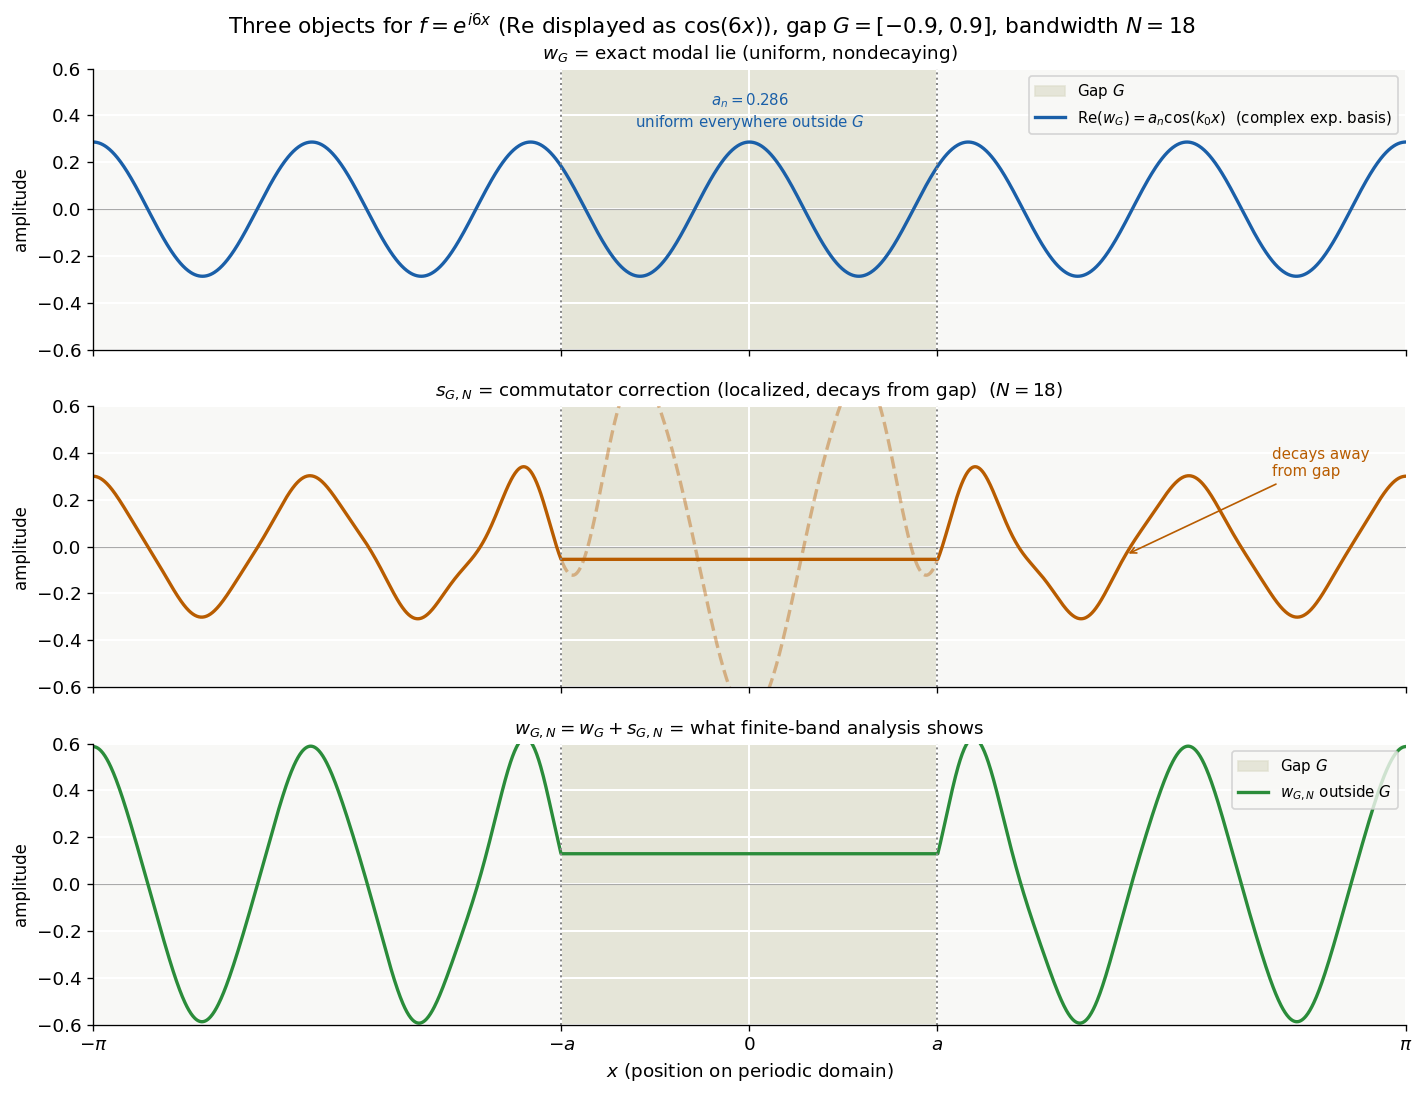

In [3]:
# --- The 1D Fourier toy model: all three objects explicitly ---
# Domain: periodic circle [-pi, pi]
# True field: f(x) = cos(k0 * x)  (a single cosine mode)
# Gap: G = [-a, a]  (symmetric interval around 0)

k0 = 6       # source mode number
a  = 0.9     # gap half-width (in radians; full gap = 2*0.9 rad ~ 103 degrees)
N  = 18      # analysis bandwidth (retain modes |m| <= N)

Nx = 2000
x = np.linspace(-np.pi, np.pi, Nx, endpoint=False)
gap_mask  = np.abs(x) <= a
out_mask  = ~gap_mask

# True field
# Source: complex exponential basis — exactly matches Part VI formulas
# (displaying Re(.) gives the cosine wave, f=cos(k0*x)=Re(e^{ik0*x}))
f = np.exp(1j * k0 * x)

# Missing mass fraction: a_n = a/pi = (1/(2pi))*int_{-a}^{a}|e^{ik0*x}|^2 dx
a_n = a / np.pi

# ---- Object 1: Exact modal lie w_G ----
# w_G(x) = c * a_n * e^{ik0*x}  (c=1 here); display Re(.)
# (spatially uniform multiplicative attenuation factor a_n; pointwise amplitude varies with the mode)
w_G = a_n * np.exp(1j * k0 * x)   # complex; Re(w_G) is the displayed phantom

# ---- Object 2: Commutator correction s_{G,N} ----
# s_{G,N}(x) = - sum_{|m|<=N} K_{m,k0} * e^{imx}    (sum includes m=k0)
# K_{m,k0} = sin((k0-m)*a) / (pi*(k0-m))   for m != k0
# K_{k0,k0} = a_n = a/pi
def K(m, k0, a):
    if m == k0:
        return a / np.pi
    return np.sin((k0 - m) * a) / (np.pi * (k0 - m))

# Build s_{G,N} by summing over ALL retained modes including m=k0.
# The commutator definition s_{G,N}(x) = -int_G Pi_N(x,y) f(y) dy expands as
#   s_{G,N}(x) = - sum_{|m|<=N} K_{m,k0} * e^{imx},
# with K_{k0,k0} = a_n = a/pi. Skipping m=k0 used to leave w_GN = w_G + (shifted s)
# which doubled the uniform amplitude outside the gap at large N. Include m=k0.
s_GN = np.zeros(Nx, dtype=complex)  # complex array: accumulates e^{imx} terms
for m in range(-N, N+1):
    Kmk = K(m, k0, a)
    s_GN -= Kmk * np.exp(1j * m * x)  # complex; display Re(.)

# ---- Object 3: Finite-band phantom w_{G,N} = w_G + s_{G,N} ----
# Outside G this equals the off-diagonal modal content: -sum_{m!=k0, |m|<=N} K_{m,k0} e^{imx}.
w_GN = w_G + s_GN

# ---- Plot ----
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Shade gap on all panels
def shade_gap(ax):
    ax.axvspan(-a, a, color='#ddddcc', alpha=0.7, label='Gap $G$')
    ax.axhline(0, color='#aaa', linewidth=0.7)

colors = ['#1a5fa8', '#b85c00', '#2a8c3a']
labels = ['$w_G$ = exact modal lie (uniform, nondecaying)',
          '$s_{G,N}$ = commutator correction (near-gap concentrated, oscillatory sidelobes)',
          '$w_{G,N} = w_G + s_{G,N}$ = what finite-band analysis shows']

# Panel 0: w_G
ax = axes[0]
shade_gap(ax)
ax.plot(x, w_G.real, color=colors[0], linewidth=2, label=r'$\mathrm{Re}(w_G) = a_n\cos(k_0 x)$  (complex exp. basis)')
ax.set_ylabel('amplitude', fontsize=10)
ax.set_title(labels[0], fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-0.6, 0.6)
ax.text(0, 0.35, f'$a_n = {a_n:.3f}$\nuniform everywhere outside $G$',
        ha='center', fontsize=9, color=colors[0])
ax.grid(True)

# Panel 1: s_{G,N}
ax = axes[1]
shade_gap(ax)
ax.plot(x[out_mask], s_GN[out_mask].real, color=colors[1], linewidth=2)
ax.plot(x[gap_mask], s_GN[gap_mask].real, color=colors[1], linewidth=2, linestyle='--', alpha=0.4)
ax.set_ylabel('amplitude', fontsize=10)
ax.set_title(f'{labels[1]}  ($N={N}$)', fontsize=11)
ax.set_ylim(-0.6, 0.6)
ax.annotate('decays away\nfrom gap', xy=(1.8, s_GN[np.argmin(np.abs(x-1.8))].real),
            xytext=(2.5, 0.3), arrowprops=dict(arrowstyle='->', color=colors[1]),
            fontsize=9, color=colors[1])
ax.grid(True)

# Panel 2: w_{G,N}
ax = axes[2]
shade_gap(ax)
ax.plot(x[out_mask], w_GN[out_mask].real, color=colors[2], linewidth=2,
        label='$w_{G,N}$ outside $G$')
ax.set_ylabel('amplitude', fontsize=10)
ax.set_title(labels[2], fontsize=11)
ax.set_xlabel('$x$ (position on periodic domain)', fontsize=11)
ax.set_ylim(-0.6, 0.6)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True)

for ax in axes:
    ax.axvline(-a, color='#888', linewidth=1.2, linestyle=':')
    ax.axvline( a, color='#888', linewidth=1.2, linestyle=':')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, -a, 0, a, np.pi])
    ax.set_xticklabels(['$-\\pi$', '$-a$', '$0$', '$a$', '$\\pi$'])

plt.tight_layout()
plt.suptitle(
    f'Three objects for $f = e^{{i{k0}x}}$ (Re displayed as $\\cos({k0}x)$),'
    f' gap $G=[-{a},{a}]$, bandwidth $N={N}$',
    y=1.01, fontsize=13)
plt.show()


---
## Part III — The Exact Energy Laws

### 3.1 Simple Spectrum: The Bernoulli Law

For simple spectrum and a single excited mode $n$, the missing $L^2$-mass fraction is $a_n = K_{nn} = \int_G|\varphi_n|^2$. Idempotency of $M_G$ gives:

**Simple-spectrum phantom energy [E]:**
$$\sum_{m\neq n}|\hat{c}_m|^2 = |c_n|^2 \cdot a_n(1-a_n).$$

The phantom fraction of measured spectral energy is exactly $a_n$. This is Bernoulli variance: the variance of a $\{0,1\}$ random variable with parameter $a_n$, evaluated at the gap fraction.

The asymmetry is crucial and non-obvious:
- $\beta = 0$ (gap misses the mode entirely): zero phantom energy. No contamination.
- $\beta = 1$ (gap captures the mode entirely): also zero phantom energy. The mode is missing from measurements but contributes no false content in other modes.
- $\beta = 1/2$: maximum phantom fabrication. The worst case.

**Complete occlusion of a mode is better than partial occlusion from a phantom fabrication standpoint.** If you cannot avoid a gap over a region where a signal exists, it is better to contain the signal entirely than to clip it. Partial coverage of a strong mode is worse than complete occlusion.

### 3.2 Degenerate Spectrum: The Eigenspace Compression

For a degenerate eigenspace $E_\lambda$ with $\dim E_\lambda = d > 1$, define the **eigenspace compression**:
$$B_\lambda = P_\lambda \chi_G P_\lambda : E_\lambda \to E_\lambda.$$

$B_\lambda$ is self-adjoint with eigenvalues $\beta_j \in [0,1]$ and mask-adapted eigenvectors $\{u_j\}$. The $\beta_j$ are the **exposure eigenvalues** — fractions of $L^2$-mass of each mask-adapted direction captured by the gap. The $\{u_j\}$ are the **exposure basis**: eigenspace directions sorted by how much the gap sees them.

**Degenerate-spectrum phantom energy [E]:**
$$\|(I - P_\lambda)M_G f\|^2 = \langle B_\lambda(I - B_\lambda)f, f\rangle = \sum_j |a_j|^2 \beta_j(1-\beta_j),$$
where $f = \sum_j a_j u_j$ in the mask-adapted eigenbasis.

This is exact for any gap geometry and any degenerate eigenspace. The simple-spectrum result is the $\dim E_\lambda = 1$ special case ($B_\lambda$ reduces to the scalar $a_n$).

### 3.3 What the Exposure Basis Means

The mask-adapted eigenbasis $\{u_j\}$ is the decomposition of the eigenspace into directions sorted by their visibility to the hole:

- $u_j$ with $\beta_j \approx 0$: this direction has almost no amplitude inside $G$. The gap barely sees it. Little phantom energy.
- $u_j$ with $\beta_j \approx 1$: this direction lives almost entirely inside $G$. The gap captures it almost completely. Also little phantom energy — but the mode is nearly invisible to the analyst.
- $u_j$ with $\beta_j \approx 1/2$: this direction straddles the gap boundary. Maximum phantom energy per unit amplitude.

For the disk with azimuthal mode $n$ and sector gap at angle $\theta_t$ of full angular extent $\Delta\theta$ (i.e.\ the sector is $[\theta_t - \Delta\theta/2,\ \theta_t+\Delta\theta/2]$), the mask-adapted eigenvalues are:
$$\beta_{\pm} = \rho_{n,m}\left(\Delta\theta \pm \frac{|\sin(n\Delta\theta)|}{n}\right),$$
where $\rho_{n,m} = c_{n,m}^2 \int_{r_1}^{r_2} J_n(k_{nm}r)^2\,r\,dr$ is the radial overlap. *(Basis convention: $c_{n,m}^2 = 1/(2\pi \int_0^R J_n(k_{nm}r)^2 r\,dr)$ is the complex-exponential normalization, giving $\rho_{n,m} \leq 1/(2\pi)$ with equality for $[r_1,r_2]=[0,R]$. In the real basis $\{\sqrt 2\cos n\theta, \sqrt 2\sin n\theta\}$ the radial normalization is $c'^2 = 2c^2$ and $\rho$ scales accordingly — the formula above is correct in either convention if $\rho$ is read consistently. See `disk.ipynb` §1.3 for the cross-walk.)*

**Accidental zeros:** when $\sin(n\Delta\theta) = 0$ (gap subtends an integer number of half-periods of the azimuthal mode), $\beta_+ = \beta_-$. The gap is **angularly blind** — it exposes both degenerate directions identically and the mask-adapted basis is arbitrary. No measurement in this configuration can distinguish the degenerate pair through the gap.

### 3.4 Multi-Mode: Covariance Transport

For general multi-mode excitation $f = \sum_n c_n \varphi_n$, the observed coefficient vector is $\hat{c} = Ac$. For an ensemble:
$$\Sigma_{\hat{c}} = A\,\Sigma_c\,A^*,$$
where $\Sigma_c = \mathbb{E}[cc^*]$ is the true covariance and $\Sigma_{\hat{c}}$ is the observed covariance. The hole applies the forward operator $A$ to the covariance in the same way it applies to the state vector. All second-order statistics are contaminated through the same coupling matrix.


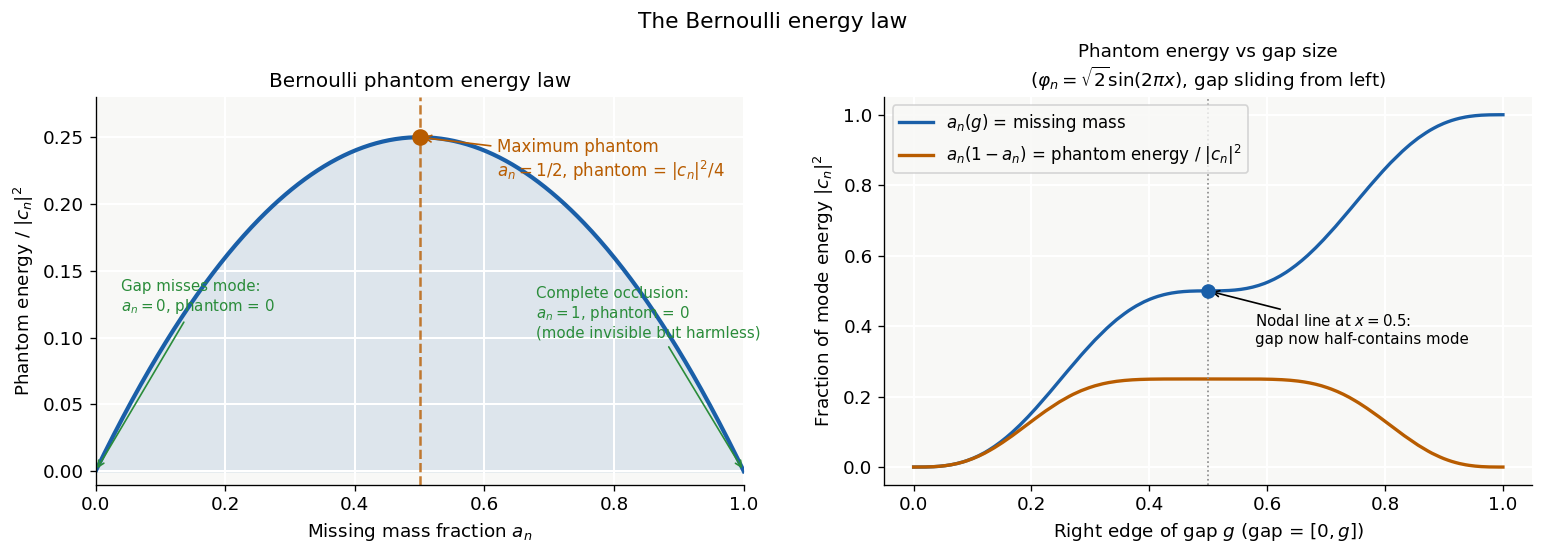

In [4]:
# --- Bernoulli curve and the asymmetry insight ---
a_vals = np.linspace(0, 1, 500)
phantom_frac = a_vals * (1 - a_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: the Bernoulli curve
ax = axes[0]
ax.plot(a_vals, phantom_frac, '#1a5fa8', linewidth=2.5)
ax.fill_between(a_vals, phantom_frac, alpha=0.12, color='#1a5fa8')
ax.axvline(0.5, color='#b85c00', linewidth=1.5, linestyle='--', alpha=0.8)
ax.scatter([0.5], [0.25], color='#b85c00', s=80, zorder=5)
ax.annotate('Maximum phantom\n$a_n=1/2$, phantom = $|c_n|^2/4$',
            xy=(0.5, 0.25), xytext=(0.62, 0.22),
            arrowprops=dict(arrowstyle='->', color='#b85c00'),
            fontsize=10, color='#b85c00')
ax.annotate('Complete occlusion:\n$a_n=1$, phantom = 0\n(mode invisible but harmless)',
            xy=(1.0, 0.0), xytext=(0.68, 0.10),
            arrowprops=dict(arrowstyle='->', color='#2a8c3a'),
            fontsize=9, color='#2a8c3a')
ax.annotate('Gap misses mode:\n$a_n=0$, phantom = 0',
            xy=(0.0, 0.0), xytext=(0.04, 0.12),
            arrowprops=dict(arrowstyle='->', color='#2a8c3a'),
            fontsize=9, color='#2a8c3a')
ax.set_xlabel(r'Missing mass fraction $a_n$', fontsize=11)
ax.set_ylabel('Phantom energy / $|c_n|^2$', fontsize=11)
ax.set_title('Bernoulli phantom energy law', fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(-0.01, 0.28)
ax.grid(True)

# Right: show what happens as gap grows — simulate a growing gap on a Dirichlet sine mode
# Domain [0,1], mode phi_n = sqrt(2)*sin(2*pi*x), gap G=[0, g] of growing size
g_vals = np.linspace(0, 1, 300)
x_fine = np.linspace(0, 1, 5000)
phi = np.sqrt(2) * np.sin(2*np.pi*x_fine)  # n=2 Dirichlet mode on [0,1], normalized
dx = x_fine[1] - x_fine[0]

a_of_g = np.array([np.sum(phi[x_fine <= g]**2)*dx for g in g_vals])
phantom_of_g = a_of_g * (1 - a_of_g)

ax2 = axes[1]
ax2.plot(g_vals, a_of_g, '#1a5fa8', linewidth=2, label='$a_n(g)$ = missing mass')
ax2.plot(g_vals, phantom_of_g, '#b85c00', linewidth=2, label='$a_n(1-a_n)$ = phantom energy / $|c_n|^2$')
ax2.axvline(0.5, color='#888', linewidth=1, linestyle=':')
ax2.set_xlabel('Right edge of gap $g$ (gap = $[0,g]$)', fontsize=11)
ax2.set_ylabel('Fraction of mode energy $|c_n|^2$', fontsize=11)
ax2.set_title(r'Phantom energy vs gap size' + '\n' + r'($\varphi_n = \sqrt{2}\sin(2\pi x)$, gap sliding from left)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True)

# Mark when gap reaches the node at x=0.5
ax2.scatter([0.5], [a_of_g[np.argmin(np.abs(g_vals-0.5))]],
            color='#1a5fa8', s=60, zorder=5)
ax2.annotate('Nodal line at $x=0.5$:\ngap now half-contains mode',
             xy=(0.5, 0.5), xytext=(0.58, 0.35),
             arrowprops=dict(arrowstyle='->'), fontsize=9)

plt.tight_layout()
plt.suptitle('The Bernoulli energy law', y=1.02, fontsize=13)
plt.show()


---
## §3.2 — Rectangular Membrane: Explicit Coupling Formula

For a domain $L \times W$ with eigenfunctions $\varphi_{mn}(x,y) = \sqrt{4/LW}\sin(m\pi x/L)\sin(n\pi y/W)$ and a rectangular gap with centroid $(x_0, y_0)$ and half-widths $(a/2, b/2)$ (i.e.\ $G = [x_0-a/2,\, x_0+a/2]\times[y_0-b/2,\, y_0+b/2]$), the coupling matrix factorizes exactly:
$$K = \frac{4}{LW}\,J^x \otimes J^y,$$
where $(J^x)_{mm_0} = \int_{x_0-a/2}^{x_0+a/2} \sin(m\pi x/L)\sin(m_0\pi x/L)\,dx$ and similarly for $J^y$.

Two types of zeros in $K_{mn,m_0n_0}$:
- **Structural zeros:** $m \neq m_0$ and $J^x_{m,m_0} = 0$ by symmetry (e.g., gap centred on a nodal line). These vanish for geometric reasons independent of the gap size.
- **Accidental zeros:** $K_{mn,m_0n_0} = 0$ for a specific combination of gap position and width, not from symmetry. These are fragile — they vanish for the nominal gap but reappear under any perturbation.


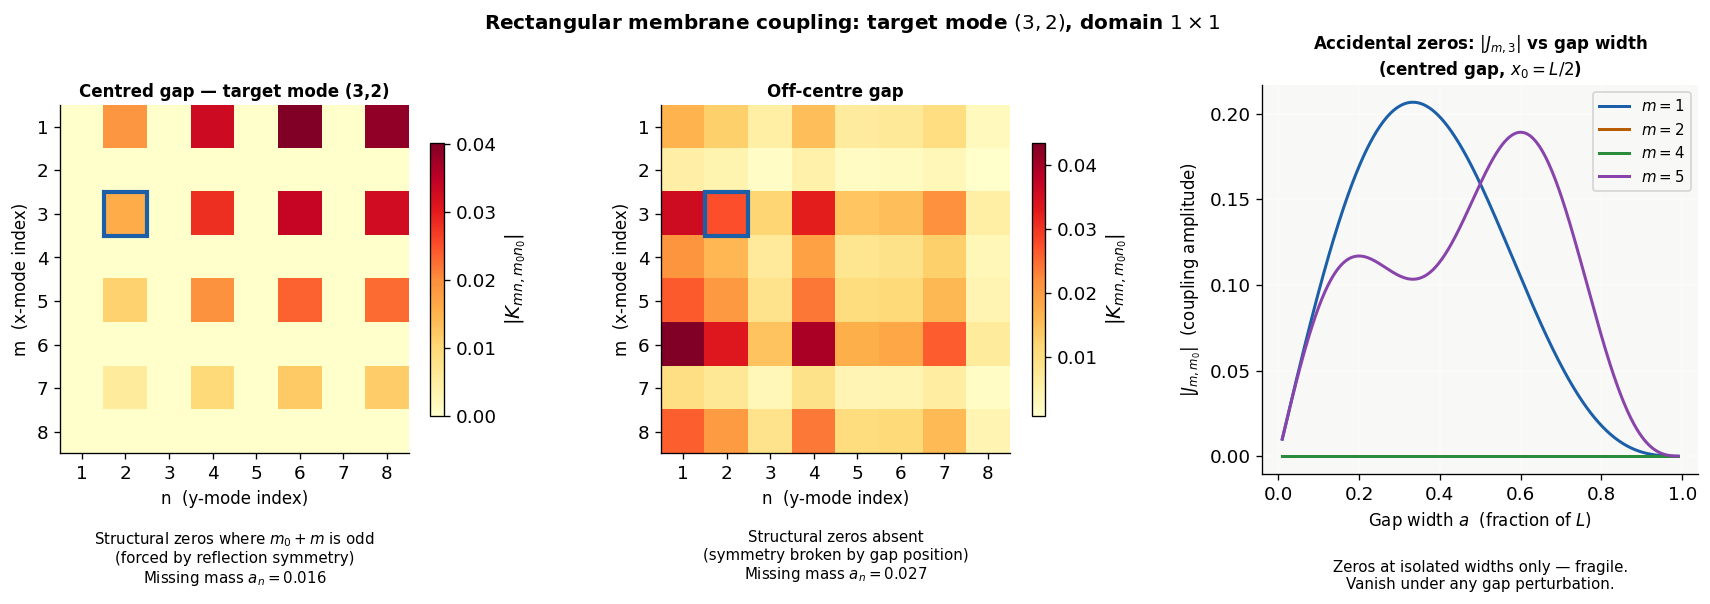

In [5]:

# Rectangular membrane: coupling matrix and structural/accidental zeros
L, W = 1.0, 1.0

def J1D(m, m0, x0, a, Ldom):
    """1D coupling integral: x0 is the GAP CENTROID, a is the FULL gap width.
    Computes integral_{x0-a/2}^{x0+a/2} sin(m*pi*x/L) sin(m0*pi*x/L) dx.
    NOTE (audit fix): text formerly described x0 as lower-left corner,
    but the formula uses cos((m0±m)*pi*x0/L) which requires x0 = centroid.
    Convention is now consistent: x0,y0 are always centroids.
    """
    if m == m0:
        return a/2 - (Ldom/(2*m0*np.pi))*np.sin(m0*np.pi*a/Ldom)*np.cos(2*m0*np.pi*x0/Ldom)
    t1 = np.sin((m0-m)*np.pi*a/(2*Ldom))*np.cos((m0-m)*np.pi*x0/Ldom)/(m0-m)
    t2 = np.sin((m0+m)*np.pi*a/(2*Ldom))*np.cos((m0+m)*np.pi*x0/Ldom)/(m0+m)
    return (Ldom/np.pi)*(t1-t2)

def coupling_K(m, n, m0, n0, x0, y0, a, b):
    return (4/(L*W))*J1D(m,m0,x0,a,L)*J1D(n,n0,y0,b,W)

m0, n0_rect = 3, 2
Nmax = 8

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.subplots_adjust(left=0.06, right=0.97, bottom=0.28, top=0.87, wspace=0.38)

def plot_K_matrix(ax, x0, y0, a, b, title, subtitle):
    K = np.zeros((Nmax,Nmax))
    for m in range(1,Nmax+1):
        for n in range(1,Nmax+1):
            K[m-1,n-1] = abs(coupling_K(m,n,m0,n0_rect,x0,y0,a,b))
    im = ax.imshow(K, cmap='YlOrRd', origin='upper',
                   extent=[0.5,Nmax+0.5,Nmax+0.5,0.5], aspect='equal')
    ax.set_xlabel('n  (y-mode index)', fontsize=10)
    ax.set_ylabel('m  (x-mode index)', fontsize=10)
    ax.set_xticks(range(1,Nmax+1)); ax.set_yticks(range(1,Nmax+1))
    ax.set_title(title, fontsize=10, fontweight='bold', pad=5)
    ax.add_patch(plt.Rectangle((n0_rect-0.5,m0-0.5),1,1,
                 fill=False, edgecolor='#1a5fa8', linewidth=2.5))
    plt.colorbar(im, ax=ax, shrink=0.7, label=r'$|K_{mn,m_0n_0}|$')
    a_n = coupling_K(m0,n0_rect,m0,n0_rect,x0,y0,a,b)
    # Caption well below the axis numbers using fig.text via ax transform
    ax.annotate(f'{subtitle}\nMissing mass $a_n = {a_n:.3f}$',
                xy=(0.5,-0.22), xycoords='axes fraction',
                ha='center', va='top', fontsize=9, color='black')

plot_K_matrix(axes[0], 0.5, 0.5, 0.25, 0.20,
              f'Centred gap — target mode ({m0},{n0_rect})',
              'Structural zeros where $m_0+m$ is odd\n(forced by reflection symmetry)')
plot_K_matrix(axes[1], 0.35, 0.40, 0.25, 0.20,
              'Off-centre gap',
              'Structural zeros absent\n(symmetry broken by gap position)')

# Accidental zeros panel
ax = axes[2]
a_scan = np.linspace(0.01,0.99,500)
for m, color in [(1,'#1a5fa8'),(2,'#b85c00'),(4,'#2a8c3a'),(5,'#8844aa')]:
    if m==m0: continue
    Jvals = [abs(J1D(m,m0,0.5,a,L)) for a in a_scan]
    ax.plot(a_scan, Jvals, color=color, linewidth=1.8, label=f'$m={m}$')
ax.set_xlabel('Gap width $a$  (fraction of $L$)', fontsize=10)
ax.set_ylabel(r'$|J_{m,m_0}|$  (coupling amplitude)', fontsize=10)
ax.set_title(f'Accidental zeros: $|J_{{m,{m0}}}|$ vs gap width\n'
             f'(centred gap, $x_0=L/2$)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
ax.annotate('Zeros at isolated widths only — fragile.\nVanish under any gap perturbation.',
            xy=(0.5,-0.22), xycoords='axes fraction',
            ha='center', va='top', fontsize=9, color='black')

fig.suptitle(f'Rectangular membrane coupling: target mode $({m0},{n0_rect})$, domain $1\\times1$',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part IV — The Three-Part Anatomy

The hole problem has three distinct engines. Knowing which engine controls which aspect determines which design rules matter and which mitigation strategies work.

### 4.1 Bulk: How Much False Content Exists

Controlled by $B_\lambda = P_\lambda \chi_G P_\lambda$ and the energy law:
$$\|w_G(f)\|^2 = \langle B_\lambda(I - B_\lambda)f, f\rangle.$$

Bulk is about what the hole captures from the source mode. It determines the total phantom energy budget — how much false spectral content is available to be redistributed across other modes.

**Bulk design rule (small-gap limit):** minimize $a_n = \int_G|\varphi_n|^2$ for the target mode. Leading-order expansion, centroid at distance $d$ from a nodal line, gap width $a$ in the direction crossing that line: $a_n \approx |G|\cdot|\nabla\varphi_n(x_\text{line})|^2 (d^2 + a^2/12) + O(a^4)$. The scaling depends on gap geometry:
- **Slit-like gap** (fixed tangential length $L_\|$, width $a$ across the nodal line): $|G| \sim L_\| a$, giving $a_n = O(a^3)$ when centered on the line.
- **Isotropic 2D gap** (size $a$ in both directions): $|G| \sim a^2$, giving $a_n = O(a^4)$ when centered on the line.

Either way, $a_n \to 0$ both as $d \to 0$ (centroid approaches the line) and as $a \to 0$ (gap shrinks). Nodal **sets** are measure-zero (no open set contains one), so the gap cannot sit "entirely within a nodal region"; what the rule means is **align the gap cross-section with a nodal line and keep the gap narrow in the crossing direction**.

### 4.2 Edge: Where the False Content Goes in Mode Space

Controlled by the coupling matrix $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$. For smooth gap boundaries and $L = -\Delta$, Green's second identity gives the exact boundary form:

**Boundary Wronskian routing law [E]:**
$$(\lambda_m - \lambda_n)K_{mn} = \int_{\partial G}[\bar{\varphi}_m\,\partial_\nu\varphi_n - \varphi_n\,\partial_\nu\bar{\varphi}_m]\,dS.$$

Off-diagonal coupling is exactly a boundary Wronskian on $\partial G$ divided by eigenvalue separation. Two immediate consequences:

**Near-resonant modes** (small $|\lambda_m - \lambda_n|$) receive larger coupling per unit boundary interaction. The phantom energy is not spectrally flat — it concentrates near modes adjacent in eigenvalue to the source.

**The dominant oscillation scale** of phantom features near $\partial G$ is set by the eigenvalue spacing near $\lambda_n$, not by the bandwidth cutoff. This is different from simple Gibbs behavior.

**Edge design rule:** to minimize coupling to specific off-target modes, minimize the Wronskian $\int_{\partial G}[\bar{\varphi}_m\partial_\nu\varphi_n - \varphi_n\partial_\nu\bar{\varphi}_m]\,dS$. This means aligning the gap boundary with regions where both the source and target eigenfunctions have small values or where their Wronskian vanishes.

### 4.3 Projector: What It Looks Like in Physical Space

The visible finite-band artifact is the commutator correction:
$$s_{G,N}(x) = -\int_G \Pi_N(x,y)\,f(y)\,dy.$$

The retained-band projector kernel $\Pi_N$ acts as a point-spread function on the removed interior field $f|_G$. The artifact has its main lobe concentrated near $\partial G$ (width $\sim\lambda_N^{-1/2}$) with global oscillatory sidelobes whose envelope decays algebraically but not monotonically — the near-gap localization is a main-lobe phenomenon, not an exponential-decay phenomenon.

**Key practical consequence:** the visible halo is controlled by both the field inside $G$ and the projector kernel geometry. The dominant contribution near $\partial G$ comes from the jump discontinuity of $\chi_G f$ across $\partial G$, since the jump drives the high-frequency content of the Dirichlet kernel.

**Boundary trace design rule** (not in the original suite):
Minimize $|\varphi_n|_{\partial G}|^2$ — the source amplitude at the gap boundary — to suppress the visible halo. This is distinct from the bulk rule (minimize $\int_G|\varphi_n|^2$). A gap that clips an antinode at its edge produces strong near-gap artifacts even with small bulk overlap.

These two design rules are independent and address different objectives:
- **Bulk rule** minimizes total phantom energy. Relevant for modal coefficient contamination.
- **Boundary trace rule** minimizes visible near-gap artifacts in finite-band reconstructions. Relevant for what practitioners see in spectrograms, mode shapes, and spatial visualizations.

They diverge when the gap straddles a nodal surface: the interior can have low $|\varphi_n|^2$ (small bulk overlap) while the boundary $\partial G$ cuts through a region where $|\varphi_n|$ is moderate (nonzero boundary trace). A standard bulk-optimized gap placement can still produce strong visible artifacts through the boundary trace mechanism.


---
## Part V — Regime Analysis

The visible phantom pattern $w_{G,N} = w_G + s_{G,N}$ depends on the analysis bandwidth $N$ in a nontrivial way. The five regimes below describe qualitatively different behaviors.

### Regime I — Complete Basis

Analysis bandwidth $N \to \infty$. Then $s_{G,N} \to 0$ and the phantom field is:
$$w_{G,N}(x) \to w_G(x) = a_n \varphi_n(x) \quad\text{for } x \notin G\text{ (simple spectrum)}.$$

Spatially uniform attenuation outside $G$: the phantom field is $a_n\varphi_n(x)$, with the **attenuation factor $a_n$ the same at every point** (pointwise amplitude $|a_n\varphi_n(x)|$ varies with $x$ through $\varphi_n$, but the multiplicative factor does not). No near-gap enhancement of the attenuation. No distance dependence. The original observation of "three near lobes, far lobe missing" does not appear at all at complete bandwidth. This regime rarely occurs in practice — every analysis system has a finite spectral bandwidth. But it is the exact limit that the energy identity (T1) describes.

### Regime II — Intermediate Finite-Band (where the observation lives)

Both $w_G$ and $s_{G,N}$ are present. Far from the gap, $s_{G,N} \to 0$ and the visible phantom approaches $w_G = a_n\varphi_n(x)$ — the spatially uniform exact lie. Near the gap, $s_{G,N}$ is large and modulates the combined amplitude through Gibbs-like oscillations near $\partial G$.

The "three lobes visible, far lobe missing" pattern is a threshold effect: near the gap, $|w_{G,N}| = |w_G + s_{G,N}|$ is elevated by the $s_{G,N}$ contribution and exceeds the detection threshold. Far from the gap, $s_{G,N} \approx 0$ and only $w_G = a_n\varphi_n(x)$ remains; if $a_n$ is small this falls below threshold. The far lobe is absent not because $s_{G,N}$ cancels $w_G$ there — the $s_{G,N}$ sidelobes fall off in amplitude ($\sim 1/|x-y|$ envelope in 1D, slower in 2D) but are not literally zero, and their time-averaged contribution decreases — but because far from $\partial G$ the visible phantom is dominated by $w_G = a_n\varphi_n$ alone, which falls below detection threshold when $a_n$ is small.

### Regime III — High Cutoff

As $N$ increases, $s_{G,N}$ confines to an increasingly thin boundary layer around $\partial G$ with width $\sim \lambda_N^{-1/2}$. Away from $\partial G$, $s_{G,N} \to 0$ and $w_{G,N} \to w_G$.

**Important reversal of intuition:** Increasing analysis bandwidth (higher $N$) makes the visible phantom **more uniform**, not less. The near-gap localization is strongest at intermediate bandwidth. High bandwidth recovers the exact global lie $w_G = a_n \varphi_n(x)$ everywhere outside $G$.

If you increase the spectral resolution of your analysis and the phantom features become more uniformly distributed rather than more localized, that is the expected behavior, not a sign of error.

### Regime IV — Point-Defect Limit

When the gap diameter is much smaller than the shortest retained wavelength: $d_G\sqrt{\lambda_N} \ll 1$. The gap emits the difference of two projector kernels centered at the centroid $x_G$:
$$w_{G,N}(x) \approx |G|\,[\Pi_\lambda - \Pi_N](x,x_G)\,f(x_G).$$
The amplitude is proportional to $|f(x_G)|$ — the field value at the centroid, not the bulk integral.

### Regime V — Ambiguity Limit

When $\mu_{\max}(C_N) \approx 1$, where $C_N = P_N \chi_G P_N$. Some retained-band modal direction concentrates almost entirely inside $G$. The analyst observing outside $G$ sees nearly the same data whether or not that direction is excited — the observable region cannot distinguish "mode present" from "mode absent" for this direction. $\mu_{\max} \to 1$ means the hole supports a convincing lie: there exists a bandlimited field that agrees with the true field outside $G$ to within the noise floor but carries completely different modal content.

---
## Part VI — The 1D Fourier Toy Model

The full hole calculus is exactly solvable on the periodic line. This is the strongest sanity check in the framework — every phenomenon appears in one explicit formula.

**Setup:** Domain $S^1$ (periodic line). Eigenbasis $\{e^{imx}\}_{m\in\mathbb{Z}}$. True source $f = e^{ik_0 x}$. Gap $G = [-a,a] \subset S^1$.

**The coupling matrix:**
$$K_{m,k_0} = \frac{1}{2\pi}\int_{-a}^{a} e^{i(k_0-m)x}\,dx = \frac{\sin((m-k_0)a)}{\pi(m-k_0)},$$
with diagonal limit $a_{k_0} = a/\pi$. Hard gap produces an exact sinc spectral tail: $K_{m,k_0} \sim 1/|m-k_0|$ for large $|m-k_0|$. Slow off-diagonal decay because the hard edge at $\pm a$ has a jump discontinuity.

**The three objects explicitly:**

Exact modal lie (outside $G$):
$$w_G(x) = \frac{a}{\pi}\,e^{ik_0 x}.$$
Uniform. Same amplitude everywhere outside $[-a,a]$. No $x$-dependence in the amplitude.

Commutator correction:
$$s_{G,N}(x) = -\frac{1}{2\pi}\int_{-a}^{a} D_N(x-y)\,e^{ik_0 y}\,dy,$$
where $D_N(t) = \sin((N+\frac{1}{2})t)/\sin(t/2)$ is the Dirichlet kernel — the projector kernel $\Pi_N(x,y)$ on the circle.

**1D hole calculus in one line:**
$$w_{G,N}(x) = \frac{a}{\pi}\,e^{ik_0 x} - \frac{1}{2\pi}\int_{-a}^{a} D_N(x-y)\,e^{ik_0 y}\,dy.$$

Global exact lie minus Dirichlet-kernel response to the removed interior. The general bounded-domain problem is this formula with $D_N$ replaced by the spectral projector kernel $\Pi_N$ of the specific domain and operator.

**What the formula shows:**
- Near $x = \pm a$ (gap boundary): $D_N(x-y)$ peaks, so $s_{G,N}$ is large and the visible phantom is dominated by Gibbs-like boundary oscillations.
- Away from $\pm a$: $D_N(x-y)$ oscillates at amplitude $\sim 1/|x-y|$ with $N$-dependent phase (not $1/(N|x-y|)$ — the extra $1/N$ factor is wrong; see Dirichlet kernel asymptotics). Away from the gap, the time-averaged contribution of $s_{G,N}$ decreases, and the visible phantom $\to (a/\pi)e^{ik_0 x}$. *(Audit fix: the $1/(N|x-y|)$ claim was incorrect. The pointwise Dirichlet kernel amplitude is $O(1/|x-y|)$ regardless of $N$.)*
- As $N \to \infty$: $D_N \to \delta$, the boundary layer sharpens to zero width, and $w_{G,N} \to w_G$ everywhere outside $G$.
- At intermediate $N$: the Dirichlet kernel has width $\sim 1/N$, creating the oscillatory pattern seen in finite-band spectral analysis.


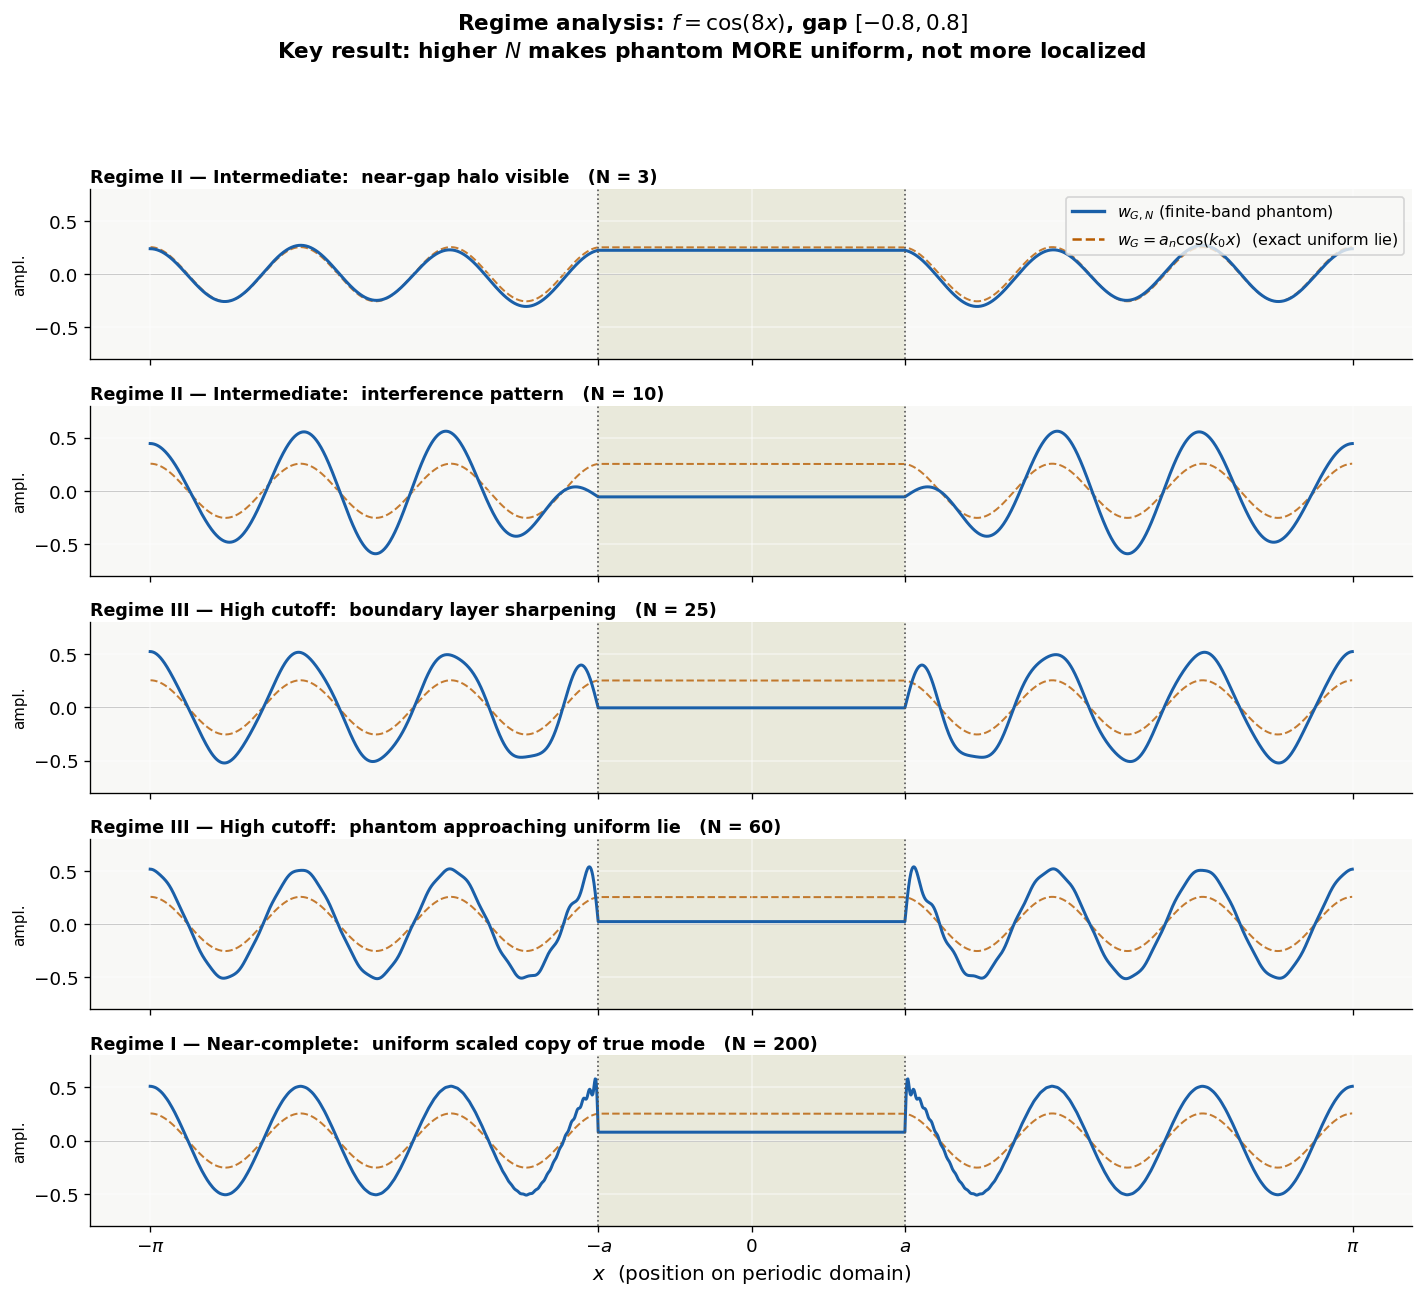

In [6]:

# Regime analysis: five values of N
k0_toy = 8
a_toy  = 0.8
N_vals = [3, 10, 25, 60, 200]

Nx2 = 2000
x2 = np.linspace(-np.pi, np.pi, Nx2, endpoint=False)
gap2  = np.abs(x2) <= a_toy
out2  = ~gap2
a_n2  = a_toy / np.pi

def compute_w_GN(x, k0, a, N):
    a_n = a / np.pi
    w_G = a_n * np.cos(k0 * x)
    # s_{G,N}(x) = -sum_{|m|<=N} K_{m,k0} * e^{imx}; include m=k0 where K_{k0,k0}=a_n.
    # (Earlier version skipped m=k0, which doubled the uniform amplitude outside G at large N.)
    s_GN = np.zeros_like(x)
    for m in range(-N, N+1):
        if m == k0:
            Km = a_n
        elif m == 0:
            Km = np.sin(k0 * a) / (np.pi * k0)
        else:
            Km = np.sin((k0 - m) * a) / (np.pi * (k0 - m))
        s_GN -= Km * np.cos(m * x)
    return w_G, s_GN, w_G + s_GN

regime_labels = {
    3:   ('II',  'Intermediate',   'near-gap halo visible'),
    10:  ('II',  'Intermediate',   'interference pattern'),
    25:  ('III', 'High cutoff',    'boundary layer sharpening'),
    60:  ('III', 'High cutoff',    'phantom approaching uniform lie'),
    200: ('I',   'Near-complete',  'uniform scaled copy of true mode'),
}

fig, axes = plt.subplots(len(N_vals), 1, figsize=(12, 11), sharex=True)
fig.suptitle(
    r'Regime analysis: $f = \cos(8x)$, gap $[-0.8, 0.8]$' + '\n'
    r'Key result: higher $N$ makes phantom MORE uniform, not more localized',
    fontsize=13, fontweight='bold')

for ax, N in zip(axes, N_vals):
    w_G2, s_GN2, w_GN2 = compute_w_GN(x2, k0_toy, a_toy, N)
    roman, regime, desc = regime_labels[N]

    ax.axvspan(-a_toy, a_toy, color='#e8e8d8', alpha=0.9, zorder=0)
    ax.plot(x2[out2], w_GN2[out2].real, color='#1a5fa8', linewidth=1.8, zorder=2)
    ax.plot(x2[out2], a_n2 * np.cos(k0_toy * x2[out2]),
            color='#b85c00', linewidth=1.2, linestyle='--', alpha=0.8, zorder=1)
    ax.set_ylim(-0.8, 0.8)
    ax.axhline(0, color='#aaa', linewidth=0.6, zorder=0)
    ax.axvline(-a_toy, color='#555', linewidth=1, linestyle=':', zorder=3)
    ax.axvline( a_toy, color='#555', linewidth=1, linestyle=':', zorder=3)
    ax.grid(True, alpha=0.4, zorder=0)
    ax.set_yticks([-0.5, 0, 0.5])
    ax.set_ylabel('ampl.', fontsize=9)

    # Label as subplot title — LEFT aligned, dark, readable
    ax.set_title(f'Regime {roman} — {regime}:  {desc}   (N = {N})',
                 loc='left', fontsize=10.5, color='black', fontweight='bold', pad=4)

axes[-1].set_xlabel(r'$x$  (position on periodic domain)', fontsize=12)
axes[-1].set_xticks([-np.pi, -a_toy, 0, a_toy, np.pi])
axes[-1].set_xticklabels([r'$-\pi$', r'$-a$', r'$0$', r'$a$', r'$\pi$'])

# Shared legend on top panel
axes[0].plot([], [], '#1a5fa8', linewidth=2, label=r'$w_{G,N}$ (finite-band phantom)')
axes[0].plot([], [], '#b85c00', linewidth=1.5, linestyle='--',
             label=r'$w_G = a_n\cos(k_0 x)$  (exact uniform lie)')
axes[0].legend(loc='upper right', fontsize=9.5)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


---
## Part VII — Degenerate Eigenspaces

### 7.1 Why Degeneracy Matters

For simple spectrum, the mask-adapted basis is trivial — there is only one eigenfunction per eigenvalue, and the phantom energy law reduces to the scalar $a_n(1-a_n)$. For degenerate spectrum, the mask-adapted basis is nontrivial and the physical content is richer: the gap selects preferred directions inside the eigenspace.

**Key conceptual distinction:** intra-eigenspace mixing is basis rotation (not phantom). Inter-eigenvalue leakage is phantom (false spectral content at a different eigenvalue). The mask-adapted basis eliminates the intra-eigenspace mixing, leaving only the inter-eigenvalue phantom as the physical fabrication. This was the main clarification over the original suite's mode-coupling language.

### 7.2 The Disk: Explicit Formulas

Eigenfunctions of $-\Delta$ on the unit disk with Dirichlet boundary conditions:
$$\psi^\pm_{n,m}(r,\theta) = c_{n,m}\,J_n(k_{n,m}r)\,e^{\pm in\theta}, \quad k_{n,m} = z_{n,m}/R.$$

For $n > 0$ each eigenvalue $\lambda_{n,m} = k_{n,m}^2$ has multiplicity 2: $E_{n,m} = \operatorname{span}\{e^{+in\theta}, e^{-in\theta}\}$ (the cos and sin pair).

For an annular-sector gap (angles $[\theta_t - \Delta\theta/2, \theta_t + \Delta\theta/2]$, radii $[r_1, r_2]$), the intra-eigenspace block $B_\lambda$ on $E_{n,m}$ (in the $\{+n,-n\}$ basis) is $\rho_{n,m}$ times:
$$\begin{pmatrix} \Delta\theta & e^{-2in\theta_t}\sin(n\Delta\theta)/n \\ e^{+2in\theta_t}\sin(n\Delta\theta)/n & \Delta\theta \end{pmatrix},$$
with radial factor $\rho_{n,m} = c_{n,m}^2 \int_{r_1}^{r_2} J_n(k_{n,m}r)^2\,r\,dr$.

Mask-adapted eigenvalues: $\beta_{\pm} = \rho_{n,m}(\Delta\theta \pm |\sin(n\Delta\theta)|/n)$.

The angular selectivity $\beta_+ - \beta_- = 2\rho|\sin(n\Delta\theta)|/n$ measures how strongly the gap distinguishes between the two degenerate directions. Accidental zeros at $n\Delta\theta = k\pi$ are the configurations where the gap has zero angular discriminating power.


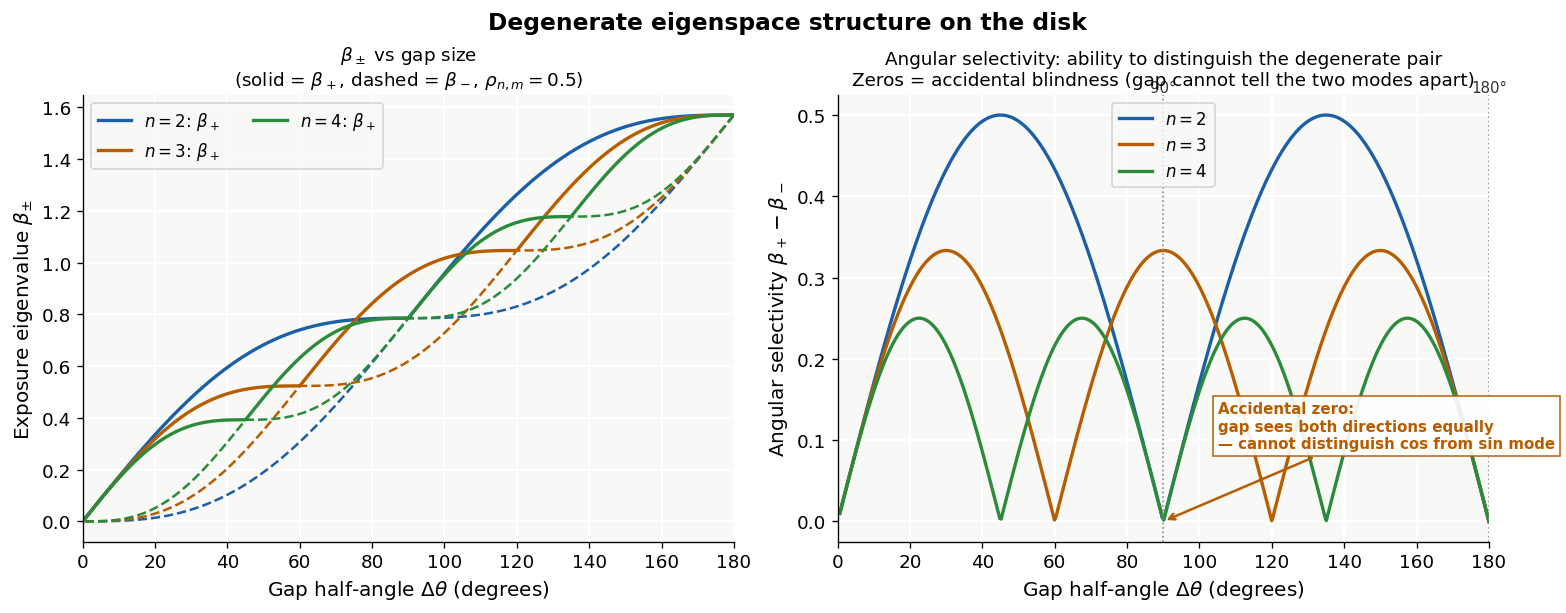

In [7]:

# Degenerate eigenspace: beta_pm vs gap angle
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         constrained_layout=True)
fig.suptitle('Degenerate eigenspace structure on the disk',
             fontsize=14, fontweight='bold')

rho = 0.50
dtheta = np.linspace(0.01, np.pi, 500)

for n, color in [(2, '#1a5fa8'), (3, '#b85c00'), (4, '#2a8c3a')]:
    beta_plus  = rho * (dtheta + np.abs(np.sin(n*dtheta)) / n)  # audit fix: β_+ = ρ(Δθ + |sin(nΔθ)|/n), no π division
    beta_minus = rho * (dtheta - np.abs(np.sin(n*dtheta)) / n)  # audit fix: β_- = ρ(Δθ - |sin(nΔθ)|/n), no π division
    diff = beta_plus - beta_minus
    axes[0].plot(np.degrees(dtheta), beta_plus,  color=color, linewidth=2,
                 label=f'$n={n}$: ' + r'$\beta_+$')
    axes[0].plot(np.degrees(dtheta), beta_minus, color=color, linewidth=1.5,
                 linestyle='--')
    axes[1].plot(np.degrees(dtheta), diff, color=color, linewidth=2, label=f'$n={n}$')

for ang in [90, 180]:
    axes[1].axvline(ang, color='#888', linewidth=1, linestyle=':')
    axes[1].text(ang, axes[1].get_ylim()[1] if axes[1].get_ylim()[1] > 0 else 0.16,
                 f'{ang}\u00b0', ha='center', va='bottom', fontsize=9, color='#333')

axes[0].set_xlabel(r'Gap angular extent $\Delta\theta$ (degrees)', fontsize=12)
axes[0].set_ylabel(r'Exposure eigenvalue $\beta_{\pm}$', fontsize=12)
axes[0].set_title(r'$\beta_\pm$ vs gap size' + '\n' +
                  r'(solid = $\beta_+$, dashed = $\beta_-$, $\rho_{n,m}=0.5$)',
                  fontsize=11)
axes[0].legend(fontsize=10, ncol=2)
axes[0].grid(True)
axes[0].set_xlim(0, 180)

axes[1].set_xlabel(r'Gap angular extent $\Delta\theta$ (degrees)', fontsize=12)
axes[1].set_ylabel(r'Angular selectivity $\beta_+ - \beta_-$', fontsize=12)
axes[1].set_title('Angular selectivity: ability to distinguish the degenerate pair\n'
                  'Zeros = accidental blindness (gap cannot tell the two modes apart)',
                  fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True)
axes[1].set_xlim(0, 180)

axes[1].annotate('Accidental zero:\ngap sees both directions equally\n'
                 '— cannot distinguish cos from sin mode',
                 xy=(90, 0), xytext=(105, 0.09),
                 arrowprops=dict(arrowstyle='->', color='#b85c00', lw=1.5),
                 fontsize=9, color='#b85c00', fontweight='bold',
                 bbox=dict(fc='white', ec='#b85c00', alpha=0.9, pad=3))

plt.show()


### 7.3 The Quantum Graph: Exact Binary Visibility

The equilateral 3-edge star graph (three edges $e_1, e_2, e_3$ of length $\ell$ joined at a central vertex with Kirchhoff conditions) has two spectral families.

The antisymmetric family has eigenvalues $\lambda_p = (p\pi/\ell)^2$ with 2D degenerate eigenspaces. The flux-balance constraint $\alpha_1 + \alpha_2 + \alpha_3 = 0$ gives an orthonormal basis:
$$\alpha^{(1)} = (1,-1,0)/\sqrt{2}, \qquad \alpha^{(2)} = (1,1,-2)/\sqrt{6}.$$

For a gap $G = [a,b] \subset e_1$ (one edge only), the eigenspace compression $B_\lambda$ is rank one:
$$\beta_1 = \frac{2}{3}\rho_p, \qquad \beta_2 = 0,$$
where $\rho_p = (2/\ell)\int_a^b \sin^2(p\pi x/\ell)\,dx$.

**The interpretation is exact and binary:**
- $\beta_2 = 0$: the direction $\alpha = (0,1,-1)/\sqrt{2}$ has zero amplitude on $e_1$. The gap cannot see it at all. Zero phantom energy for this direction.
- $\beta_1 = (2/3)\rho_p$: the direction $\alpha = (2,-1,-1)/\sqrt{6}$ has maximum amplitude on $e_1$. The gap sees it. Phantom energy $\beta_1(1-\beta_1)$.

This is the sharpest illustration in the entire framework. The mask-adapted basis is not a technical mathematical convenience — it is the decomposition into "visits the gapped wire" and "avoids the gapped wire." The distinction is physically transparent and the result is exact with no quadrature error.

### 7.4 Small-Gap Visibility Rank

For a $d$-dimensional eigenspace and a gap with $d_G\sqrt{\lambda_N} \ll 1$:
$$B_\lambda \approx |G|\,v_\lambda v_\lambda^*, \qquad v_\lambda = (u_1(x_G), \ldots, u_d(x_G)).$$

The leading-order exposure operator is rank one. One eigenspace direction is maximally visible; the remaining $d-1$ are invisible at monopole order.

*Correction from v1:* the rank-one approximation applies when $v_\lambda \neq 0$. If all eigenspace basis functions vanish at $x_G$ (the nodal set of the entire eigenspace), the monopole term is zero, $B_\lambda \approx 0$ at leading order, and the dipole term leads. The expansion exists everywhere — what changes at nodal points is the leading coefficient, not the existence of the expansion.


beta_+ = 0.03473,  beta_- = 0.02715
Phantom energy (formula): 0.029966
Phantom energy (numeric): 0.030381
Relative error: 1.38%


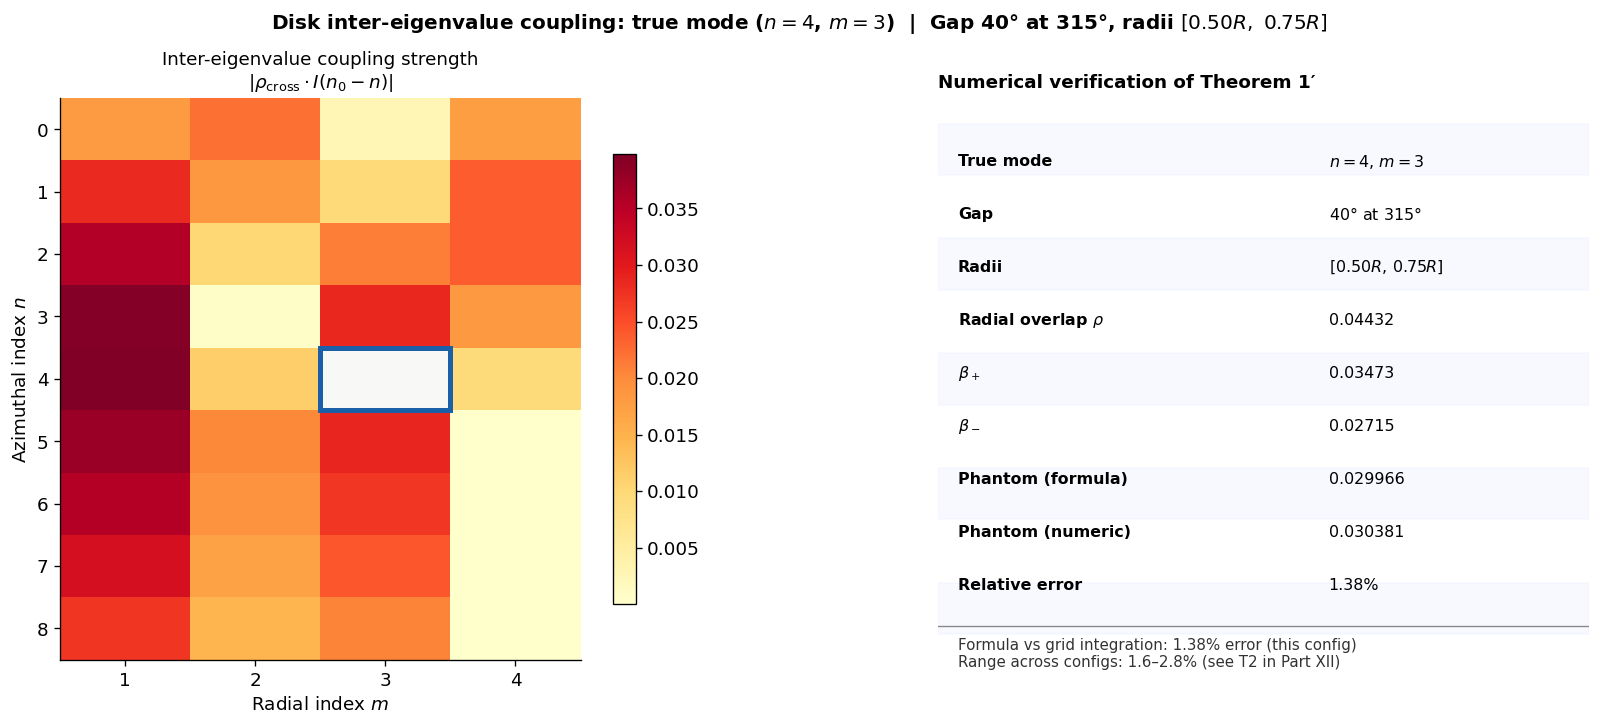

In [8]:

# Disk inter-eigenvalue coupling + numerical verification of Theorem 1'
from scipy.special import jv

_bz = {0:[2.4048,5.5201,8.6537,11.7915],1:[3.8317,7.0156,10.1735,13.3237],
       2:[5.1356,8.4172,11.6198,14.7960],3:[6.3802,9.7610,13.0152,16.2235],
       4:[7.5883,11.0647,14.3725,17.6160],5:[8.7715,12.3386,15.7002,18.9801]}
def bz(n,m): return _bz[min(n,5)][m-1]
R = 1.0

def rad_norm(n,m):
    z = bz(n,m)
    return 1.0/(np.sqrt(np.pi)*R*abs(jv(n+1,z)))

def rad_overlap(n1,m1,n2,m2,r1,r2,nr=2000):
    r = np.linspace(r1,r2,nr)
    return np.trapezoid(jv(n1,bz(n1,m1)/R*r)*jv(n2,bz(n2,m2)/R*r)*r,r)*rad_norm(n1,m1)*rad_norm(n2,m2)

def Iang(ell,theta_t,dtheta):
    if ell==0: return dtheta
    return np.exp(1j*ell*theta_t)*2*np.sin(ell*dtheta/2)/ell

n0v,m0v = 4,3
theta_t = 315*np.pi/180; dtheta = 40*np.pi/180
r1v,r2v = 0.5*R,0.75*R

rho = rad_overlap(n0v,m0v,n0v,m0v,r1v,r2v)
sin_t = np.sin(n0v*dtheta)/n0v
I2n = Iang(2*n0v,theta_t,dtheta)
B = rho*np.array([[dtheta,np.conj(I2n)],[I2n,dtheta]])  # audit fix: off-diag = ρ·Iang(2n), not ρ·Iang(2n)·sin_t (sin_t² was wrong)
betas = sorted(np.linalg.eigvalsh(B))  # bug fix: dropped .real — B is Hermitian complex; .real discards off-diag phase and silently fails for e^{2in*theta_t} != 1 (e.g. n=3)
beta_m,beta_p = betas
phantom_formula = 0.5*(beta_p*(1-beta_p)+beta_m*(1-beta_m))

Nr_g,Nth_g = 200,400
r_g = np.linspace(0,R,Nr_g); th_g = np.linspace(0,2*np.pi,Nth_g,endpoint=False)
Rg,Thg = np.meshgrid(r_g,th_g,indexing='ij')
cn0 = rad_norm(n0v,m0v)
phi       = cn0*jv(n0v,bz(n0v,m0v)/R*Rg)*np.exp( 1j*n0v*Thg)  # ψ⁺
psi_minus = cn0*jv(n0v,bz(n0v,m0v)/R*Rg)*np.exp(-1j*n0v*Thg)  # ψ⁻ (second basis vector of E_λ)
gm = ((np.abs(Thg-theta_t)<=dtheta/2)|(np.abs(Thg-theta_t-2*np.pi)<=dtheta/2)
       |(np.abs(Thg-theta_t+2*np.pi)<=dtheta/2))&(Rg>=r1v)&(Rg<=r2v)
dA = Rg*(r_g[1]-r_g[0])*(2*np.pi/Nth_g)
phi_m = phi.copy(); phi_m[gm]=0
# Degenerate phantom energy: project off the whole eigenspace E_λ = span{ψ⁺, ψ⁻},
# not just ψ⁺. ||(I − P_λ) M_G ψ⁺||² = ||M_G ψ⁺||² − |⟨M_G ψ⁺, ψ⁺⟩|² − |⟨M_G ψ⁺, ψ⁻⟩|²
inner_plus  = np.sum(phi_m*np.conj(phi)      *dA)
inner_minus = np.sum(phi_m*np.conj(psi_minus)*dA)
phantom_num = (np.sum(np.abs(phi_m)**2*dA)
               - np.abs(inner_plus)**2
               - np.abs(inner_minus)**2).real

print(f'beta_+ = {beta_p:.5f},  beta_- = {beta_m:.5f}')
print(f'Phantom energy (formula): {phantom_formula:.6f}')
print(f'Phantom energy (numeric): {phantom_num:.6f}')
print(f'Relative error: {abs(phantom_num-phantom_formula)/phantom_formula*100:.2f}%')

fig = plt.figure(figsize=(14, 6))
fig.subplots_adjust(left=0.06, right=0.97, top=0.86, bottom=0.08, wspace=0.35)
ax_map = fig.add_subplot(1,2,1)
ax_tbl = fig.add_subplot(1,2,2)

n_range = list(range(0,9)); m_range = list(range(1,5))
Kmap = np.zeros((len(n_range),len(m_range)))
for i,n in enumerate(n_range):
    for j,m in enumerate(m_range):
        if n==n0v and m==m0v: Kmap[i,j]=np.nan; continue
        rho_c = rad_overlap(n0v,m0v,min(n,5),m,r1v,r2v)
        Kmap[i,j] = abs(rho_c*Iang(n0v-n,theta_t,dtheta))
im = ax_map.imshow(Kmap,cmap='YlOrRd',origin='upper',aspect='auto',
                   extent=[0.5,len(m_range)+0.5,len(n_range)-0.5,-0.5])
ax_map.set_xlabel('Radial index $m$',fontsize=11)
ax_map.set_ylabel('Azimuthal index $n$',fontsize=11)
ax_map.set_xticks(range(1,len(m_range)+1))
ax_map.set_yticks(range(len(n_range))); ax_map.set_yticklabels([str(n) for n in n_range])
ax_map.set_title('Inter-eigenvalue coupling strength\n'+r'$|\rho_{\rm cross}\cdot I(n_0-n)|$',fontsize=11)
ax_map.add_patch(plt.Rectangle((m0v-0.5,n0v-0.5),1,1,fill=False,edgecolor='#1a5fa8',linewidth=3))
plt.colorbar(im,ax=ax_map,shrink=0.8)

# Verification table — right panel
ax_tbl.axis('off')
ax_tbl.set_title('Numerical verification of Theorem 1\u2032',fontsize=11,fontweight='bold',loc='left')

rows = [
    ('True mode',      f'$n={n0v}$, $m={m0v}$'),
    ('Gap',            f'${int(np.degrees(dtheta))}\\degree$ at ${int(np.degrees(theta_t))}\\degree$'),
    ('Radii',          f'$[{r1v:.2f}R,\\, {r2v:.2f}R]$'),
    ('Radial overlap $\\rho$', f'{rho:.5f}'),
    ('$\\beta_+$',     f'{beta_p:.5f}'),
    ('$\\beta_-$',     f'{beta_m:.5f}'),
    ('Phantom (formula)', f'{phantom_formula:.6f}'),
    ('Phantom (numeric)', f'{phantom_num:.6f}'),
    ('Relative error', f'{abs(phantom_num-phantom_formula)/phantom_formula*100:.2f}%'),
]
# Draw table with lines — all inside the axes, no overflow
n_rows = len(rows)
row_h = 0.85 / n_rows  # fits all rows in 85% height
y0 = 0.93
for k, (label, val) in enumerate(rows):
    y = y0 - k*row_h
    bg = '#f0f4ff' if k%2==0 else 'white'
    ax_tbl.axhspan(y-row_h*0.9, y, xmin=0, xmax=1, color=bg, alpha=0.5, transform=ax_tbl.transAxes)
    ax_tbl.text(0.03, y-row_h*0.45, label, fontsize=9.5, fontweight='bold',
                va='center', transform=ax_tbl.transAxes)
    ax_tbl.text(0.60, y-row_h*0.45, val, fontsize=9.5,
                va='center', transform=ax_tbl.transAxes)

# Divider and note — within the remaining space
ax_tbl.plot([0,1],[0.06,0.06],'#888',linewidth=0.8,transform=ax_tbl.transAxes)
ax_tbl.text(0.03, 0.04,
    f'Formula vs grid integration: {abs(phantom_num-phantom_formula)/phantom_formula*100:.2f}% error (this config)\n'
    f'Range across configs: 1.6\u20132.8% (see T2 in Part XII)',
    transform=ax_tbl.transAxes, fontsize=9, va='top', color='#333')

fig.suptitle(f'Disk inter-eigenvalue coupling: true mode ($n={n0v}$, $m={m0v}$)  |  '
             f'Gap {int(np.degrees(dtheta))}\u00b0 at {int(np.degrees(theta_t))}\u00b0, '
             f'radii $[{r1v:.2f}R,\\ {r2v:.2f}R]$',
             fontsize=12, fontweight='bold')
plt.show()


---
## Part VIII — Recoverability

### 8.1 The Ambiguity Operator

The **concentration operator** $C_N = P_N \chi_G P_N$ is the compression of the hard mask into the retained spectral band. Its eigenvalues $\mu_j \in [0,1]$ measure how much of each retained-band direction lies inside $G$.

The forward operator $A_N = I - C_N$ has condition number:
$$\kappa_2(A_N) = \frac{1-\mu_{\min}}{1-\mu_{\max}}.$$

$\mu_{\max} \to 1$ means some modal combination concentrates almost entirely inside $G$. The visible data outside $G$ can barely distinguish this direction from zero. The **ambiguity basis** — the near-1 eigenspace of $C_N$ — is the set of directions the hole nearly erases.

Practical interpretation: $\mu_{\max}$ is the strength of the hole as an ambiguity generator. A hole with $\mu_{\max} \approx 0.1$ barely compromises recovery. A hole with $\mu_{\max} \approx 0.9$ makes recovery of one specific modal direction almost impossible from a single measurement.

### 8.2 Recovery Strategies

Given $\hat{c} = A_N c$ (noiseless) and known gap geometry:

- **$\mu_{\max} \ll 1$:** $A_N$ is well-conditioned. Direct inversion $c = A_N^{-1}\hat{c}$ works.
- **$\mu_{\max}$ moderate:** regularized inversion. Tikhonov: solve $(A_N^*A_N + \alpha I)c = A_N^*\hat{c}$.
- **$\mu_{\max} \approx 1$:** the hidden direction cannot be recovered from this measurement. Take a second measurement with a different gap geometry.

For sparse excitation: $\ell^1$ recovery solves $\min\|c\|_1$ subject to $A_N c = \hat{c}$. For noiseless data with $\mu_{\max} < 1$, $\mathrm{null}(A_N) = \{0\}$, so the NSP is vacuously satisfied and exact $\ell^1$ recovery works for any sparsity level. Sparsity is a regularizer for noise, not an identifiability tool.

**Noise-robust bound:** $\|A_N^*A_N - I\| = \mu_{\max}(2-\mu_{\max})$. *(Note: an earlier version of this document incorrectly had $\mu_{\max}(2+\mu_{\max})$. The correct formula follows from factoring $\|K^2-2K\|$ with eigenvalues $\mu(\mu-2)$.)*

### 8.3 Multi-Gap Synthesis

Take measurements with different gap geometries $G_1, \ldots, G_K$, each giving $\hat{c}_k = A_{N,k}c$. Stack:
$$[\hat{c}_1;\ldots;\hat{c}_K] = [A_{N,1};\ldots;A_{N,K}]\,c.$$

**Multi-gap design principle:** choose gap geometries so that the ambiguity bases (near-1 eigenspaces of $C_N^{(1)},\ldots,C_N^{(K)}$) are mutually transverse. If the same modal direction hides in every gap, stacking provides no improvement. If the hidden directions are different for each gap, their combination recovers all of them.

For $K$ complementary partial measurements in the **rank-1-complement partition sense** ($A_k = I - e_k e_k^*$ with $\{e_k\}$ orthonormal in mode space — each measurement blind to one direction and covering fraction $(K-1)/K$) — the stacked operator satisfies $\sigma_{\min}([A_1;\ldots;A_K]) \geq \sqrt{K-1}$, or equivalently for the $1/\sqrt K$-normalized stack, $\sigma_{\min}\big((1/\sqrt K)[A_1;\ldots;A_K]\big) \geq \sqrt{(K-1)/K}\to 1$ as $K\to\infty$. (A different bound, $\sigma_{\min}\geq (K-1)/\sqrt K$, applies to the **physical-space partition** setup $A_k = I - P_N\chi_{G_k}P_N$ with $\sum_k \chi_{G_k} = I$; see `ccg.ipynb` §5.3. Both setups deserve the name "complementary" but the bounds are different: for $K=2$, rank-1-complement gives $\sigma_{\min}\geq 1$, physical-space partition gives $\sigma_{\min}\geq 1/\sqrt 2$.) *(The unnormalized $\sigma_{\min}$ grows like $\sqrt{K}$, not to a fixed limit; the "$\to 1$" behaviour belongs to the normalized stack. Corrected from an earlier version.)*

---
## Part IX — Downstream Observable Contamination

The contamination does not stop at phantom modal coefficients. Any quantity computed from those coefficients inherits the corruption. The pipeline computes $Q(\hat{c}) = Q(Ac)$ when the intended quantity is $Q(c)$. Unless $Q$ is invariant under the mask operator, the output is wrong in a deterministic, predictable way.

### 9.1 The Interaction Matrix

For the modal interaction matrix $O(c) = cc^*$:
$$\hat{I} = \hat{c}\hat{c}^* = Acc^*A^* = AIA^*.$$

A true rank-$r$ excitation produces an observed interaction matrix that is generically full rank. Every mode pair $(m,n)$ acquires a cross-term nonzero even when the true field has no content at those indices. This is a false interaction — deterministic, geometry-dependent, exactly predicted by $K$.

### 9.2 Specific False Observables

**False coherence:** phantom coefficients from the same source mode are perfectly coherent ($|\gamma^2| = 1$). Physically uncoupled modes appear correlated through the gap's spectral coupling.

**False bispectra:** third-order spectral peaks appear at $(k_1, k_2)$ without any physical three-wave interaction, from quadratic mixing of phantom coefficients.

**False damping:** $\hat{c}_m(t)$ evolves at $\omega_{n_0}$ (source frequency), not $\omega_m$ (phantom mode's eigenfrequency). A damping estimate tracking $\hat{c}_m(t)$ measures the source's decay rate but reports it as mode $m$'s damping.

**False detections:** thresholding promotes phantom peaks into false targets, false wave systems, or false structural modes. Unlike noise-induced false alarms, these are coherent, repeatable, and predicted by $K$.

### 9.3 Temporal Inheritance Detection

For time-evolving $f(x,t)$ with a static mask: $\hat{c}_m(t) = A_{m,n_0}\cdot c(t)$ (single source mode $n_0$). Every phantom inherits the source's temporal dynamics. Three detection tests:

**Dispersion test:** temporal FFT of $\hat{c}_m(t)$ should peak at $\omega_m$ for a genuine mode. For a phantom it peaks at $\omega_{n_0}$. Requires known dispersion relation.

**Coherence test:** $|\gamma^2(\hat{c}_m, c_{n_0})| = 1$ for phantoms. Genuine independent modes: $|\gamma^2| < 1$. **Geometry-independent** — works even without knowing the gap geometry.

**K-amplitude test:** $|\hat{c}_m|/|\hat{c}_{n_0}| = |K_{m,n_0}|/|1 - K_{n_0 n_0}|$. Requires known gap geometry. Fastest: amplitude is one number per mode.

All three are exact for a static mask. For time-varying masks, phantoms acquire frequency sidebands from mask motion and dispersion/coherence tests can fail.


---
## Part X — The Multipole Expansion

The rank-one (monopole) approximation for a small gap centered at $x_G$:
$$K_{mn} \approx |G|\,\varphi_n(x_G)\,\bar{\varphi}_m(x_G).$$

This is the leading term of a Taylor expansion of $\varphi_n(y)\bar{\varphi}_m(y)$ about $x_G$, integrated over $G$:

$$K_{mn} = |G|F_{mn}(x_G) + M_j\,\partial_j F_{mn}(x_G) + \tfrac{1}{2}Q_{jk}\,\partial_{jk}F_{mn}(x_G) + \cdots$$

where $F_{mn}(x) = \varphi_n(x)\bar{\varphi}_m(x)$, $M_j = \int_G(y-x_G)_j\,dy$ (first moments; vanish for centrosymmetric $G$), and $Q_{jk} = \int_G(y-x_G)_j(y-x_G)_k\,dy$ (second moments; encode shape and orientation).

The Taylor expansion exists everywhere in $\Omega$ — eigenfunctions of elliptic operators are smooth on the interior. At a nodal point of $\varphi_n(x_G)\bar{\varphi}_m(x_G)$, the monopole coefficient $F_{mn}(x_G) = 0$ and the dipole term leads.

**What the higher moments encode:**
- **Monopole:** area × eigenfunction products at centroid. Same for all gaps with the same area and centroid.
- **Dipole:** gap asymmetry / offset from centroid. Vanishes for centrosymmetric gaps.
- **Quadrupole:** gap shape anisotropy and principal orientation. Two round gaps and one elliptical gap with the same area and centroid differ first at quadrupole order.

*Practical consequence:* two instruments with the same nominal gap area and centroid but different gap shapes produce identical contamination at monopole order and diverge at quadrupole order. The difference is computable from the geometry without running any simulation.

---
## Part XI — Engineering Deliverables

Three engineering tools that are directly implementable and not available in current practice.

### 11.1 The Gap Susceptibility Map

Before any data collection: compute $|K_{mn}|$ for the gap geometry and eigenfunctions. Output: a table indexed by $(m,n)$ mode pairs. Row $n$ gives the modes that will show false peaks if mode $n$ is excited, and the predicted amplitude ratios $|\hat{c}_m|/|\hat{c}_n| = |K_{mn}|/|1-K_{nn}|$.

**Usage:** flag susceptible spectral bins before analysis. In sensor networks, use $K$ to prioritize which ghost peaks to investigate. In radar, predict which wavenumber bins will contain gap-induced false targets.

**Limitation:** $K$ inherits all uncertainty from the eigenfunction model. FE model errors propagate directly to $K$ errors.

### 11.2 The Dual Design Rule

Standard practice uses one design rule: minimize $\int_G|\varphi_n|^2$ (align the gap cross-section with a nodal line and keep the gap narrow in the crossing direction). The framework adds: also minimize $|\varphi_n|_{\partial G}|^2$ (put the gap boundary on a nodal line).

When these rules agree (gap cross-section aligned with a nodal line, narrow in the crossing direction), standard practice is sufficient. When they conflict — a gap straddling a nodal surface has small interior overlap but large boundary trace — standard practice optimizes total phantom energy but leaves visible near-gap artifacts unaddressed.

**Dual design rule:** for finite-band analysis systems, apply both rules. Prioritize the boundary trace rule for suppressing visible artifacts; apply the bulk rule for minimizing total false spectral content.

### 11.3 The Forward Check

Given gap geometry and estimated source spectrum:
1. Compute $A = I - K$ from the gap geometry and eigenfunctions.
2. Compute the predicted contaminated interaction: $\hat{I}_{\text{pred}} = A\,I_{\text{est}}\,A^*$.
3. Compare to the measured $\hat{I}_{\text{meas}}$. Residual $= \hat{I}_{\text{meas}} - \hat{I}_{\text{pred}}$.

If the residual is within uncertainty bounds, the measurement is consistent with gap contamination alone. If it exceeds those bounds, something physical is present that cannot be explained by the gap geometry.

This turns "beware of gap artifacts" from a qualitative warning into a quantitative calibration and detection procedure.

**Limitation:** requires both $K$ (known gap geometry) and $I_{\text{est}}$ (estimated source spectrum).


---
## Part XII — Theorem Status

**Legend:** [E] = algebraic identity, established. [K] = follows from known results. [O] = open theorem candidate.

**[E] T1 — Simple-Spectrum Energy Identity**
$$\sum_{m\neq n}|\hat{c}_m|^2 = |c_n|^2 \cdot a_n(1-a_n).$$
Exact algebraic consequence of $M_G^2 = M_G$.

**[E] T2 — Degenerate-Spectrum Energy Identity**
$$\|(I-P_\lambda)M_G f\|^2 = \langle B_\lambda(I-B_\lambda)f, f\rangle = \sum_j|a_j|^2\beta_j(1-\beta_j).$$
Exact for $f \in E_\lambda$. Numerically verified (disk PDE cross-check): grid-based quadrature agrees with the $\beta_{\pm}$ formula to 1.6–2.8%, consistent with first-order Riemann sum error on a hard-edged mask.

**[E] T3 — Decomposition Theorem**
$$w_{G,N} = w_G + s_{G,N}.$$
Exact for $f \in E_\lambda \cap \operatorname{Ran} P_N$.

**[E] T4 — Boundary Wronskian Identity**
$$(\lambda_m - \lambda_n)K_{mn} = \int_{\partial G}[\bar{\varphi}_m\,\partial_\nu\varphi_n - \varphi_n\,\partial_\nu\bar{\varphi}_m]\,dS.$$
Exact for $L = -\Delta$ and smooth $\partial G$. Follows from Green's second identity on $G$. *Note: the rectangular gap in §3.2 has corners where $\partial G$ is not smooth; the Wronskian integral requires distributional treatment at corner points and T4 as stated does not apply directly there.*

**[E] T5 — Masked Dictionary Gram Matrix**
$$\langle M_G\varphi_n, M_G\varphi_m\rangle = A_{mn}.$$
Exact for hard mask. $M_G^2 = M_G$ gives $\langle M_G\varphi_n, M_G\varphi_m\rangle = \langle M_G\varphi_n, \varphi_m\rangle = A_{mn}$.

**[O] T6 — Boundary-Layer Localization**
For $f \in E_\lambda$, the commutator correction $s_{G,N}$ concentrates in a tubular neighborhood of $\partial G$ of width $O(\lambda_N^{-1/2})$, with amplitude at $\partial G$ controlled by $|f|_{\partial G}|$.
*Status: open.* Qualitatively correct from the formula $s_{G,N}(x) = -\int_G \Pi_N(x,y)f(y)\,dy$ and known decay of $\Pi_N$. The quantitative tube width and profile require Hörmander's local Weyl law. The 1D Fourier case is proved explicitly. The general case is the missing formal theorem. *(An earlier version of the companion CCG document incorrectly marked this [K].)*

**[K] T7 — Multipole Expansion**
$$K_{mn} = \sum_{|\alpha|\leq k} m_\alpha\,\partial^\alpha(\varphi_n\bar{\varphi}_m)(x_G) + O(|G|\,d_G^{k+1}).$$
Follows from Taylor's theorem. Eigenfunctions of elliptic operators are smooth on the interior.

**[K] T8 — Visibility-Rank for Degeneracies**
For $d$-dimensional $E_\lambda$ and $d_G\sqrt{\lambda_N} \ll 1$: $B_\lambda$ has rank at most one at monopole order, and rank exactly one when $v_\lambda \neq 0$. Follows from T7.

**[O] T9 — Multi-Gap Transversality Bound**
$\sigma_{\min}([A_1;\ldots;A_K])^2 \geq f(\theta_{\min})$ where $\theta_{\min}$ is the minimum principal angle between the ambiguity bases.
*Status: open.* The geometric direction is correct. The explicit form of $f$ is the missing piece.


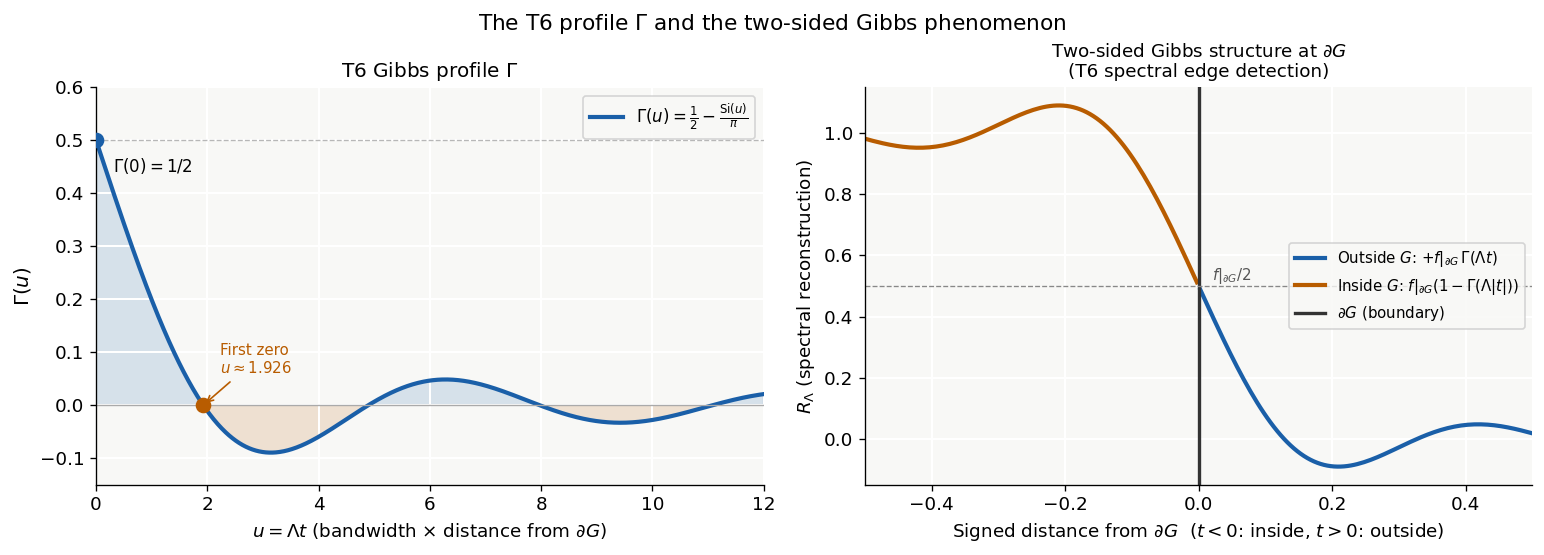

Gamma(0) = 0.500000  (should be 0.5)
First zero at u = 1.9264  (should be ~1.9264)
Gamma'(0) = -0.3183  (= -1/pi)


In [9]:
# --- The Gamma profile (T6 Gibbs function) ---
from scipy.special import sici

def Gamma(u):
    si, _ = sici(np.maximum(u, 1e-10))
    return 0.5 - si/np.pi

u = np.linspace(0, 12, 1000)
G = Gamma(u)

# First zero
u_zero = brentq(Gamma, 1.5, 2.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(u, G, '#1a5fa8', linewidth=2.5, label=r'$\Gamma(u) = \frac{1}{2} - \frac{\mathrm{Si}(u)}{\pi}$')
ax.axhline(0, color='#aaa', linewidth=0.8)
ax.axhline(0.5, color='#888', linewidth=0.8, linestyle='--', alpha=0.6)
ax.scatter([0], [0.5], color='#1a5fa8', s=70, zorder=5)
ax.scatter([u_zero], [0], color='#b85c00', s=70, zorder=5)
ax.annotate(f'$\\Gamma(0) = 1/2$', xy=(0, 0.5), xytext=(0.3, 0.44), fontsize=10)
ax.annotate(f'First zero\n$u \\approx {u_zero:.3f}$', xy=(u_zero, 0), xytext=(u_zero+0.3, 0.06),
            arrowprops=dict(arrowstyle='->', color='#b85c00'), fontsize=9, color='#b85c00')
ax.fill_between(u, G, 0, where=G>0, alpha=0.15, color='#1a5fa8')
ax.fill_between(u, G, 0, where=G<0, alpha=0.15, color='#b85c00')
ax.set_xlabel('$u = \\Lambda t$ (bandwidth × distance from $\\partial G$)', fontsize=11)
ax.set_ylabel('$\\Gamma(u)$', fontsize=12)
ax.set_title('T6 Gibbs profile $\\Gamma$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True)
ax.set_xlim(0, 12); ax.set_ylim(-0.15, 0.6)

# Right: two-sided profile (inside and outside)
t = np.linspace(-6/3, 6/3, 800)  # scaled distance
Lambda = 15  # bandwidth

outside = t > 0
inside  = t < 0

ax2 = axes[1]
# Outside: R_Lambda = +f|_G * Gamma(Lambda*t)
ax2.plot(t[outside], Gamma(Lambda*t[outside]), '#1a5fa8', linewidth=2.5,
         label='Outside $G$: $+f|_{\\partial G}\\,\\Gamma(\\Lambda t)$')
# Inside: R_Lambda = f|_G * (1 - Gamma(Lambda*|t|))
ax2.plot(t[inside], 1-Gamma(Lambda*np.abs(t[inside])), '#b85c00', linewidth=2.5,
         label='Inside $G$: $f|_{\\partial G}(1-\\Gamma(\\Lambda|t|))$')
ax2.axvline(0, color='#333', linewidth=2, label='$\\partial G$ (boundary)')
ax2.axhline(0.5, color='#888', linewidth=0.8, linestyle='--')
ax2.text(0.02, 0.52, '$f|_{\\partial G}/2$', fontsize=9, color='#555')
ax2.set_xlabel('Signed distance from $\\partial G$  ($t < 0$: inside, $t > 0$: outside)', fontsize=11)
ax2.set_ylabel('$R_\\Lambda$ (spectral reconstruction)', fontsize=11)
ax2.set_title('Two-sided Gibbs structure at $\\partial G$\n(T6 spectral edge detection)', fontsize=11)
ax2.legend(fontsize=9, loc='center right')
ax2.grid(True)
ax2.set_xlim(-0.5, 0.5)

plt.tight_layout()
plt.suptitle('The T6 profile $\\Gamma$ and the two-sided Gibbs phenomenon', y=1.02, fontsize=13)
plt.show()

print(f"Gamma(0) = {Gamma(1e-8):.6f}  (should be 0.5)")
print(f"First zero at u = {u_zero:.4f}  (should be ~1.9264)")
print(f"Gamma'(0) = {-1/np.pi:.4f}  (= -1/pi)")


---
## Part XIII — Development Record

### What the Original Suite Had Right

The exact energy identities T1 and T2 — the suite's strongest results. The two-compression structure: $B_\lambda$ (phantom energy) vs $C_N$ (conditioning). The masked dictionary observation (T5). The downstream propagation story: $\hat{I} = AIA^*$, false coherence, false damping, temporal inheritance tests. The structural vs. accidental zero distinction in $K_{mn}$. The annulus and quantum graph examples.

### What the Original Suite Got Wrong or Was Unclear

Conflated the exact outside-gap phantom (uniform, nondecaying) with the finite-band visible artifact (localized, Gibbs-like). The $w_G / s_{G,N}$ separation resolves this.

The scattering analogy document (`scattering_analogy.ipynb`) originally said the phantom field "does not satisfy a PDE." Wrong: $(-\Delta-\lambda_n)(M\varphi_n) = [-\Delta,M]\varphi_n$ is a forced Helmholtz equation. The phantom field satisfies a reduced forced PDE. What it does not do is carry new physical energy.

The finite-band localization theorem was presented as an open mystery. It is the Gibbs behavior of $s_{G,N} = -\int_G \Pi_N(\cdot,y)f(y)\,dy$ — not mysterious, just not yet formally proved with explicit bounds.

"Five communities solved the same equation": overstated. CMB and geodesy are literal siblings. SAR is a structural parallel. Seismology and structural monitoring are more distant cousins.

### Analysis Contributions (Claude)

The forced Helmholtz formulation: $(-\Delta-\lambda_n)(M\varphi_n) = [-\Delta,M]\varphi_n$ with automatic solvability. The boundary Wronskian identity T4. The Bernoulli asymmetry: $\beta=1$ (complete occlusion) is safe; $\beta=1/2$ is worst case. The NSP resolution: for noiseless data with $\mu_{\max} < 1$, exact recovery is trivial via direct inversion; $\ell^1$ is a noise regularizer, not an identifiability tool. The rank-one asymptotic as local tomography: the gap interrogates the eigenfunction family through the evaluation vector $v^{(N)} = (\varphi_1(x_G),\ldots,\varphi_N(x_G))$.

### Analysis Contributions (ChatGPT)

The $w_G / s_{G,N} / w_{G,N}$ decomposition formalized as three distinct objects — the most important single conceptual clarification in the entire discussion. The commutator formula $s_{G,N} = [P_N, M_G]f = -\int_G \Pi_N(\cdot,y)f(y)\,dy$. The regime analysis (Regime III: high bandwidth recovers the uniform exact lie, not increased localization — counterintuitive and correct). The boundary trace design rule: minimize $|\varphi_n|_{\partial G}|^2$ as a second distinct rule. The three-basis structure: exposure, fabrication, ambiguity. The contrast kernel formula.

### Errors Corrected

- T6 was labeled [K] in an earlier version. Correct label is [O].
- RIP bound: $\mu_{\max}(2-\mu_{\max})$ not $\mu_{\max}(2+\mu_{\max})$.
- Complementary-gap $\sigma_{\min} = 1/\sqrt{2}$ was stated as equality. It is a lower bound.
- Nodal set claim in multipole section: the Taylor expansion exists everywhere; the monopole term vanishes at nodal points.
- Visibility-rank: "rank one" should be "rank at most one, rank exactly one when $v_\lambda \neq 0$."
- Pointwise energy: $a_n$ fraction is a global $L^2$ statement, not pointwise.
- Phantom field "does not satisfy a PDE": wrong. Corrected.

### Open Problems

1. T6 boundary-layer localization theorem with explicit Hörmander-type bounds on tube width and Gibbs profile.
2. T9 transversality lower bound: explicit form of $f(\theta_{\min})$.
3. $\mu_{\max}$ bounds from gap geometry without solving the full eigenvalue problem — needed for practical sensor placement.
4. Extension to time-varying masks: how does temporal mask variation affect the phantom spectrum and coherence-based detection tests?
5. Experimental validation on a physical system.
